# MobiPhysio — Organized Modeling Notebook

MobiPhysio is an AI-based home physiotherapy support prototype. The user uploads a physiotherapy exercise video, Computer Vision extracts body-pose movement, ML models predict the exercise and estimate movement quality, then an LLM writes simple patient-friendly feedback.

**Dataset:** MobiPhysio contains 2D physiotherapy exercise videos for 9 active range-of-motion exercises. The modeling data used here is a prepared pose dataset extracted with YOLO Pose: 45 frames per video, 17 COCO keypoints per frame, and 3 values per keypoint `(x, y, confidence)`. The quality target is a physiotherapist-based score from 0 to 100.


## Notebook Flow

1. Setup and load the prepared pose data  
2. Train baseline models  
3. Train engineered-feature models  
4. Train XGBoost models  
5. Train kinematic quality-regression models  
6. Tune the selected Random Forest using a loss-like curve  
7. Run Experiment 4: GRU temporal regression  
8. Run Experiment 5: TCN with normalized pose and reference features  
9. Select the best model using validation results  
10. Evaluate once on the held-out test set  
11. Run error analysis and LLM feedback layer


## 1. Environment Setup
This cell imports the required libraries and sets the random seed.


In [1]:
import os
import json
import time
import copy
import random
import warnings
from pathlib import Path
from typing import Optional, Dict, Any, List
from dataclasses import dataclass, asdict
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    ExtraTreesRegressor,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)


Device: cuda
NumPy: 2.1.3
PyTorch: 2.11.0+cu128


## 2. Google Drive and Project Paths
This cell mounts Google Drive and creates the main project paths.


In [2]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/Tuwaiq Capstone Project")

ORIGINAL_PREPARED_DIR = PROJECT_DIR / "prepared_data"
BALANCED_PREPARED_DIR = PROJECT_DIR / "prepared_data_score_balanced"

# Use score-balanced data if it exists, otherwise use the original prepared data.
PREPARED_DATA_DIR = BALANCED_PREPARED_DIR if BALANCED_PREPARED_DIR.exists() else ORIGINAL_PREPARED_DIR

CSV_PATH = PROJECT_DIR / "MobiPhysio_annotations_cleaned_long.csv"
POSE_DIR = PROJECT_DIR / "pose_all"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "outputs"
LLM_OUTPUT_DIR = RESULTS_DIR / "llm_feedback"

for folder in [MODELS_DIR, RESULTS_DIR, LLM_OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Prepared data:", PREPARED_DATA_DIR)
print("Models folder:", MODELS_DIR)
print("Outputs folder:", RESULTS_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/Tuwaiq Capstone Project
Prepared data: /content/drive/MyDrive/Tuwaiq Capstone Project/prepared_data_score_balanced
Models folder: /content/drive/MyDrive/Tuwaiq Capstone Project/models
Outputs folder: /content/drive/MyDrive/Tuwaiq Capstone Project/outputs


## 3. Load Prepared Pose Data
This cell loads the train, validation, and test arrays from Drive.


In [3]:
def load_array(data_dir: Path, name: str, dtype=None):
    path = data_dir / name
    assert path.exists(), f"Missing file: {path}"
    arr = np.load(path)
    return arr.astype(dtype) if dtype is not None else arr


def load_metadata(data_dir: Path, split: str):
    candidates = [
        data_dir / f"{split}_metadata.csv",
        data_dir / f"meta_{split}.csv",
    ]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError(f"No metadata file found for {split} in {data_dir}")


X_train = load_array(PREPARED_DATA_DIR, "X_train.npy", np.float32)
X_val = load_array(PREPARED_DATA_DIR, "X_val.npy", np.float32)
X_test = load_array(PREPARED_DATA_DIR, "X_test.npy", np.float32)

y_exercise_train = load_array(PREPARED_DATA_DIR, "y_exercise_train.npy", np.int64)
y_exercise_val = load_array(PREPARED_DATA_DIR, "y_exercise_val.npy", np.int64)
y_exercise_test = load_array(PREPARED_DATA_DIR, "y_exercise_test.npy", np.int64)

y_score_train = load_array(PREPARED_DATA_DIR, "y_score_train.npy", np.float32)
y_score_val = load_array(PREPARED_DATA_DIR, "y_score_val.npy", np.float32)
y_score_test = load_array(PREPARED_DATA_DIR, "y_score_test.npy", np.float32)

meta_train = load_metadata(PREPARED_DATA_DIR, "train")
meta_val = load_metadata(PREPARED_DATA_DIR, "val")
meta_test = load_metadata(PREPARED_DATA_DIR, "test")

# Load mapping from balanced folder if available, otherwise from the original prepared folder.
mapping_candidates = [
    PREPARED_DATA_DIR / "exercise_label_mapping.json",
    ORIGINAL_PREPARED_DIR / "exercise_label_mapping.json",
]
exercise_to_idx = None
for path in mapping_candidates:
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            exercise_to_idx = json.load(f)
        break

if exercise_to_idx is None:
    exercise_codes = sorted(meta_train["exercise_code"].unique())
    exercise_to_idx = {code: i for i, code in enumerate(exercise_codes)}

idx_to_exercise = {int(v): k for k, v in exercise_to_idx.items()}

# Keep score available inside metadata for later display.
for df, scores in [
    (meta_train, y_score_train),
    (meta_val, y_score_val),
    (meta_test, y_score_test),
]:
    if "quality_score" not in df.columns:
        df["quality_score"] = np.asarray(scores).reshape(-1)

print("Train:", X_train.shape, y_exercise_train.shape, y_score_train.shape)
print("Val:  ", X_val.shape, y_exercise_val.shape, y_score_val.shape)
print("Test: ", X_test.shape, y_exercise_test.shape, y_score_test.shape)
print("Exercises:", idx_to_exercise)


Train: (2117, 45, 17, 3) (2117,) (2117,)
Val:   (553, 45, 17, 3) (553,) (553,)
Test:  (340, 45, 17, 3) (340,) (340,)
Exercises: {0: 'E01', 1: 'E02', 2: 'E03', 3: 'E04', 4: 'E05', 5: 'E06', 6: 'E07', 7: 'E08', 8: 'E09'}


## 4. Data Sanity Check
This cell checks the pose shape, score range, and participant split.


In [4]:
assert X_train.shape[1:] == (45, 17, 3)
assert X_val.shape[1:] == (45, 17, 3)
assert X_test.shape[1:] == (45, 17, 3)

assert not np.isnan(X_train).any()
assert not np.isnan(X_val).any()
assert not np.isnan(X_test).any()

assert y_score_train.min() >= 0 and y_score_train.max() <= 100
assert y_score_val.min() >= 0 and y_score_val.max() <= 100
assert y_score_test.min() >= 0 and y_score_test.max() <= 100

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "videos": [len(X_train), len(X_val), len(X_test)],
    "participants": [
        meta_train["participant_id"].nunique(),
        meta_val["participant_id"].nunique(),
        meta_test["participant_id"].nunique(),
    ],
    "score_mean": [
        y_score_train.mean(),
        y_score_val.mean(),
        y_score_test.mean(),
    ],
    "score_min": [
        y_score_train.min(),
        y_score_val.min(),
        y_score_test.min(),
    ],
    "score_max": [
        y_score_train.max(),
        y_score_val.max(),
        y_score_test.max(),
    ],
})

display(split_summary.round(2))

train_p = set(meta_train["participant_id"].astype(str))
val_p = set(meta_val["participant_id"].astype(str))
test_p = set(meta_test["participant_id"].astype(str))

assert train_p.isdisjoint(val_p)
assert train_p.isdisjoint(test_p)
assert val_p.isdisjoint(test_p)

print("Prepared-data validation passed.")


,split,videos,participants,score_mean,score_min,score_max
0,train,2117,17,81.769997,0.000000,100.0
1,validation,553,4,84.019997,57.139999,100.0
2,test,340,3,83.120003,35.709999,100.0


Prepared-data validation passed.


## 5. Baseline Features
This cell flattens the raw pose sequence for baseline models.


In [5]:
def flatten_pose(X):
    return X.reshape(X.shape[0], -1).astype(np.float32)


X_train_raw = flatten_pose(X_train)
X_val_raw = flatten_pose(X_val)
X_test_raw = flatten_pose(X_test)

print("Original pose shape:", X_train.shape)
print("Raw flattened feature shape:", X_train_raw.shape)


Original pose shape: (2117, 45, 17, 3)
Raw flattened feature shape: (2117, 2295)


## 6. Baseline Classification
This cell trains a Random Forest classifier on raw flattened pose features.


In [6]:
# ============================================================
# 7.2 Baseline Classification — Random Forest
# ============================================================

baseline_cls = RandomForestClassifier(
    n_estimators=30,
    max_features="sqrt",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

baseline_cls.fit(X_train_raw, y_exercise_train)

baseline_val_pred_class = baseline_cls.predict(X_val_raw)

baseline_val_accuracy = accuracy_score(y_exercise_val, baseline_val_pred_class)
baseline_val_precision = precision_score(
    y_exercise_val, baseline_val_pred_class,
    average="weighted", zero_division=0
)
baseline_val_recall = recall_score(
    y_exercise_val, baseline_val_pred_class,
    average="weighted", zero_division=0
)
baseline_val_f1 = f1_score(
    y_exercise_val, baseline_val_pred_class,
    average="weighted", zero_division=0
)

print("=== Baseline Classification — Validation ===")
print(f"Accuracy : {baseline_val_accuracy:.4f}")
print(f"Precision: {baseline_val_precision:.4f}")
print(f"Recall   : {baseline_val_recall:.4f}")
print(f"F1-score : {baseline_val_f1:.4f}")


=== Baseline Classification — Validation ===
Accuracy : 0.8499
Precision: 0.8534
Recall   : 0.8499
F1-score : 0.8483


## 7. Baseline Regression
This cell trains a Random Forest regressor on raw flattened pose features.


In [7]:
# ============================================================
# 7.3 Baseline Regression — Random Forest
# ============================================================

baseline_reg = RandomForestRegressor(
    n_estimators=30,
    max_features="sqrt",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

baseline_reg.fit(X_train_raw, y_score_train)

baseline_val_pred_score = baseline_reg.predict(X_val_raw)

baseline_val_mae = mean_absolute_error(y_score_val, baseline_val_pred_score)
baseline_val_rmse = np.sqrt(mean_squared_error(y_score_val, baseline_val_pred_score))
baseline_val_r2 = r2_score(y_score_val, baseline_val_pred_score)

print("=== Baseline Regression — Validation ===")
print(f"MAE : {baseline_val_mae:.4f}")
print(f"RMSE: {baseline_val_rmse:.4f}")
print(f"R²  : {baseline_val_r2:.4f}")


=== Baseline Regression — Validation ===
MAE : 10.4496
RMSE: 12.5330
R²  : 0.0042


## 8. Engineered Pose Features
This cell creates statistical and movement features from the pose sequence.


In [8]:
# ============================================================
# 8.1 Feature Engineering
# ============================================================

def extract_engineered_features(X):
    features = []

    for sample in X:
        xy = sample[:, :, :2]       # (45, 17, 2)
        conf = sample[:, :, 2]      # (45, 17)

        sample_features = []

        # Spatial/statistical features
        sample_features.extend(np.mean(xy, axis=0).flatten())
        sample_features.extend(np.std(xy, axis=0).flatten())
        sample_features.extend(np.min(xy, axis=0).flatten())
        sample_features.extend(np.max(xy, axis=0).flatten())

        # Temporal movement magnitude
        movement = np.diff(xy, axis=0)
        movement_mag = np.sqrt(np.sum(movement ** 2, axis=-1))
        sample_features.extend(np.mean(movement_mag, axis=0).flatten())

        # Average confidence
        sample_features.extend(np.mean(conf, axis=0).flatten())

        features.append(sample_features)

    return np.asarray(features, dtype=np.float32)


X_train_eng = extract_engineered_features(X_train)
X_val_eng = extract_engineered_features(X_val)
X_test_eng = extract_engineered_features(X_test)

print("Engineered feature shape:", X_train_eng.shape)
print("Raw feature count:", 45 * 17 * 3)
print("Engineered feature count:", X_train_eng.shape[1])

assert X_train_eng.shape[1] == X_val_eng.shape[1] == X_test_eng.shape[1]


Engineered feature shape: (2117, 170)
Raw feature count: 2295
Engineered feature count: 170


## 9. Experiment 1 — Random Forest with Engineered Features
This cell trains the engineered-feature Random Forest classifier.


In [9]:
# ============================================================
# 8.2 Experiment 1 Classification — Random Forest
# ============================================================

exp1_cls = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

exp1_cls.fit(X_train_eng, y_exercise_train)

exp1_val_pred_class = exp1_cls.predict(X_val_eng)

exp1_val_accuracy = accuracy_score(y_exercise_val, exp1_val_pred_class)
exp1_val_precision = precision_score(
    y_exercise_val, exp1_val_pred_class,
    average="weighted", zero_division=0
)
exp1_val_recall = recall_score(
    y_exercise_val, exp1_val_pred_class,
    average="weighted", zero_division=0
)
exp1_val_f1 = f1_score(
    y_exercise_val, exp1_val_pred_class,
    average="weighted", zero_division=0
)

print("=== Experiment 1 Classification — Validation ===")
print(f"Accuracy : {exp1_val_accuracy:.4f}")
print(f"Precision: {exp1_val_precision:.4f}")
print(f"Recall   : {exp1_val_recall:.4f}")
print(f"F1-score : {exp1_val_f1:.4f}")


=== Experiment 1 Classification — Validation ===
Accuracy : 0.9168
Precision: 0.9206
Recall   : 0.9168
F1-score : 0.9156


## 10. Experiment 1 — Regression with Engineered Features
This cell trains the engineered-feature Random Forest regressor.


In [10]:
# ============================================================
# 8.3 Experiment 1 Regression — Random Forest
# ============================================================

exp1_reg = RandomForestRegressor(
    n_estimators=100,
    max_features="sqrt",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

exp1_reg.fit(X_train_eng, y_score_train)

exp1_val_pred_score = exp1_reg.predict(X_val_eng)

exp1_val_mae = mean_absolute_error(y_score_val, exp1_val_pred_score)
exp1_val_rmse = np.sqrt(mean_squared_error(y_score_val, exp1_val_pred_score))
exp1_val_r2 = r2_score(y_score_val, exp1_val_pred_score)

print("=== Experiment 1 Regression — Validation ===")
print(f"MAE : {exp1_val_mae:.4f}")
print(f"RMSE: {exp1_val_rmse:.4f}")
print(f"R²  : {exp1_val_r2:.4f}")


=== Experiment 1 Regression — Validation ===
MAE : 10.0947
RMSE: 12.0040
R²  : 0.0865


## 11. Experiment 2 — XGBoost Setup
This cell creates the XGBoost classification and regression models.


In [11]:
try:
    from xgboost import XGBClassifier, XGBRegressor
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    from xgboost import XGBClassifier, XGBRegressor

xgb_classifier = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(idx_to_exercise),
    eval_metric="mlogloss",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

xgb_regressor = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

print("XGBoost models created.")


XGBoost models created.


## 12. Experiment 2 — XGBoost Classification
This cell trains the XGBoost classifier on engineered pose features.


In [12]:
# ============================================================
# 9.2 Experiment 2 Classification — XGBoost
# ============================================================

xgb_classifier.fit(X_train_eng, y_exercise_train)

exp2_val_pred_class = xgb_classifier.predict(X_val_eng)

exp2_val_accuracy = accuracy_score(y_exercise_val, exp2_val_pred_class)
exp2_val_precision = precision_score(
    y_exercise_val, exp2_val_pred_class,
    average="weighted", zero_division=0
)
exp2_val_recall = recall_score(
    y_exercise_val, exp2_val_pred_class,
    average="weighted", zero_division=0
)
exp2_val_f1 = f1_score(
    y_exercise_val, exp2_val_pred_class,
    average="weighted", zero_division=0
)

print("=== Experiment 2 Classification — Validation ===")
print(f"Accuracy : {exp2_val_accuracy:.4f}")
print(f"Precision: {exp2_val_precision:.4f}")
print(f"Recall   : {exp2_val_recall:.4f}")
print(f"F1-score : {exp2_val_f1:.4f}")


=== Experiment 2 Classification — Validation ===
Accuracy : 0.9114
Precision: 0.9198
Recall   : 0.9114
F1-score : 0.9100


## 13. Experiment 2 — XGBoost Regression
This cell trains the XGBoost regressor on engineered pose features.


In [13]:
# ============================================================
# 9.3 Experiment 2 Regression — XGBoost
# ============================================================

xgb_regressor.fit(X_train_eng, y_score_train)

exp2_val_pred_score = xgb_regressor.predict(X_val_eng)

exp2_val_mae = mean_absolute_error(y_score_val, exp2_val_pred_score)
exp2_val_rmse = np.sqrt(mean_squared_error(y_score_val, exp2_val_pred_score))
exp2_val_r2 = r2_score(y_score_val, exp2_val_pred_score)

print("=== Experiment 2 Regression — Validation ===")
print(f"MAE : {exp2_val_mae:.4f}")
print(f"RMSE: {exp2_val_rmse:.4f}")
print(f"R²  : {exp2_val_r2:.4f}")


=== Experiment 2 Regression — Validation ===
MAE : 10.0423
RMSE: 12.1686
R²  : 0.0613


## 14. Kinematic Quality Features
This cell builds motion-quality features such as angles, speed, acceleration, symmetry, and confidence.


In [14]:
# ============================================================
# 9.4.1 Kinematic feature engineering for quality regression
# ============================================================

from sklearn.ensemble import ExtraTreesRegressor

# COCO-17 keypoint indices
NOSE = 0
L_SHOULDER, R_SHOULDER = 5, 6
L_ELBOW, R_ELBOW = 7, 8
L_WRIST, R_WRIST = 9, 10
L_HIP, R_HIP = 11, 12
L_KNEE, R_KNEE = 13, 14
L_ANKLE, R_ANKLE = 15, 16

ANGLE_TRIPLETS = {
    "left_elbow": (L_SHOULDER, L_ELBOW, L_WRIST),
    "right_elbow": (R_SHOULDER, R_ELBOW, R_WRIST),
    "left_shoulder": (L_ELBOW, L_SHOULDER, L_HIP),
    "right_shoulder": (R_ELBOW, R_SHOULDER, R_HIP),
    "left_hip": (L_SHOULDER, L_HIP, L_KNEE),
    "right_hip": (R_SHOULDER, R_HIP, R_KNEE),
    "left_knee": (L_HIP, L_KNEE, L_ANKLE),
    "right_knee": (R_HIP, R_KNEE, R_ANKLE),
}

SYMMETRY_PAIRS = [
    ("left_elbow", "right_elbow"),
    ("left_shoulder", "right_shoulder"),
    ("left_hip", "right_hip"),
    ("left_knee", "right_knee"),
]

def _safe_stats(x):
    x = np.asarray(x, dtype=np.float32)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return [0.0] * 8
    return [
        float(np.mean(x)),
        float(np.std(x)),
        float(np.min(x)),
        float(np.percentile(x, 25)),
        float(np.median(x)),
        float(np.percentile(x, 75)),
        float(np.max(x)),
        float(np.max(x) - np.min(x)),
    ]

def _angle_series(xy, a, b, c):
    """Angle ABC in degrees for every frame."""
    ba = xy[:, a] - xy[:, b]
    bc = xy[:, c] - xy[:, b]

    ba_norm = np.linalg.norm(ba, axis=1)
    bc_norm = np.linalg.norm(bc, axis=1)
    denom = np.maximum(ba_norm * bc_norm, 1e-8)

    cosine = np.sum(ba * bc, axis=1) / denom
    cosine = np.clip(cosine, -1.0, 1.0)
    return np.degrees(np.arccos(cosine)).astype(np.float32)

def extract_kinematic_quality_features(X):
    output = []

    for sample in X:
        xy = sample[:, :, :2].astype(np.float32)
        conf = sample[:, :, 2].astype(np.float32)

        f = []

        # 1) Per-keypoint position distribution
        for kp in range(xy.shape[1]):
            f.extend(_safe_stats(xy[:, kp, 0]))
            f.extend(_safe_stats(xy[:, kp, 1]))

        # 2) Velocity and acceleration magnitude
        velocity = np.diff(xy, axis=0)
        speed = np.linalg.norm(velocity, axis=-1)

        acceleration = np.diff(velocity, axis=0)
        accel_mag = np.linalg.norm(acceleration, axis=-1)

        for kp in range(xy.shape[1]):
            f.extend(_safe_stats(speed[:, kp]))
            f.extend(_safe_stats(accel_mag[:, kp]))

        # 3) Joint-angle trajectories and angular velocity
        angle_cache = {}
        for name, (a, b, c) in ANGLE_TRIPLETS.items():
            angles = _angle_series(xy, a, b, c)
            angle_cache[name] = angles

            f.extend(_safe_stats(angles))

            angular_velocity = np.diff(angles)
            f.extend(_safe_stats(np.abs(angular_velocity)))

        # 4) Left/right symmetry
        for left_name, right_name in SYMMETRY_PAIRS:
            symmetry_error = np.abs(
                angle_cache[left_name] - angle_cache[right_name]
            )
            f.extend(_safe_stats(symmetry_error))

        # 5) Torso orientation / stability
        shoulder_mid = (xy[:, L_SHOULDER] + xy[:, R_SHOULDER]) / 2.0
        hip_mid = (xy[:, L_HIP] + xy[:, R_HIP]) / 2.0
        torso_vec = shoulder_mid - hip_mid

        torso_angle = np.degrees(
            np.arctan2(torso_vec[:, 0], -torso_vec[:, 1] + 1e-8)
        )
        f.extend(_safe_stats(torso_angle))

        hip_motion = np.linalg.norm(np.diff(hip_mid, axis=0), axis=1)
        shoulder_motion = np.linalg.norm(np.diff(shoulder_mid, axis=0), axis=1)
        f.extend(_safe_stats(hip_motion))
        f.extend(_safe_stats(shoulder_motion))

        # 6) Whole-body movement energy / smoothness
        global_speed = np.mean(speed, axis=1)
        global_accel = np.mean(accel_mag, axis=1)
        f.extend(_safe_stats(global_speed))
        f.extend(_safe_stats(global_accel))

        # 7) Pose confidence
        f.extend(_safe_stats(conf.flatten()))
        f.extend(np.mean(conf, axis=0).tolist())

        output.append(f)

    return np.asarray(output, dtype=np.float32)

def exercise_one_hot(labels, n_classes):
    labels = np.asarray(labels, dtype=np.int64)
    out = np.zeros((len(labels), n_classes), dtype=np.float32)
    out[np.arange(len(labels)), labels] = 1.0
    return out

def build_quality_feature_matrix(X, X_basic_eng, exercise_labels):
    kin = extract_kinematic_quality_features(X)
    ex = exercise_one_hot(exercise_labels, len(idx_to_exercise))
    return np.hstack([X_basic_eng, kin, ex]).astype(np.float32)

X_train_quality = build_quality_feature_matrix(
    X_train, X_train_eng, y_exercise_train
)
X_val_quality = build_quality_feature_matrix(
    X_val, X_val_eng, y_exercise_val
)

print("Basic engineered features :", X_train_eng.shape[1])
print("Enhanced quality features :", X_train_quality.shape[1])
print("Train quality matrix       :", X_train_quality.shape)


Basic engineered features : 170
Enhanced quality features : 948
Train quality matrix       : (2117, 948)


## 15. Random Forest Loss-like Curve
This cell tunes the number of trees for the kinematic Random Forest using validation MAE.


Training until trees: 10
Training until trees: 50
Training until trees: 100
Training until trees: 200
Training until trees: 400


,n_estimators,train_MAE,validation_MAE,train_RMSE,validation_RMSE,validation_R2
0,10,4.0243,9.4517,5.9299,11.7550,0.1240
1,50,3.7612,9.2040,5.4747,11.4324,0.1714
2,100,3.7065,9.1174,5.4010,11.3444,0.1841
3,200,3.6760,9.1702,5.3357,11.4178,0.1735
4,400,3.6659,9.1843,5.3241,11.4595,0.1675


Best number of trees: 100
Best validation MAE: 9.117377934274673


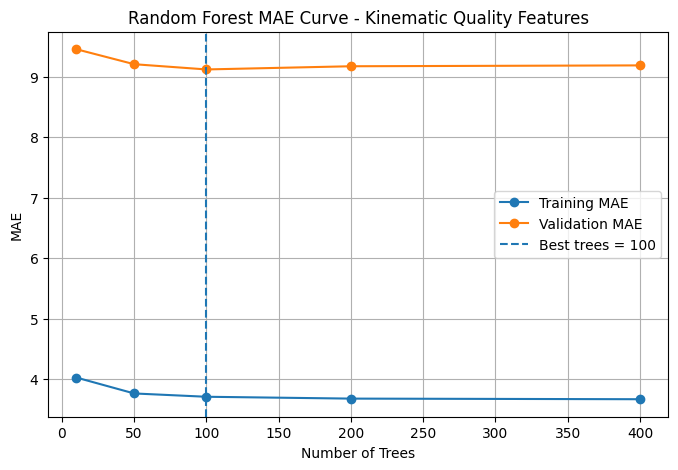

Saved: /content/drive/MyDrive/Tuwaiq Capstone Project/outputs/rf_kinematic_tree_curve.csv


In [15]:
X_tr = np.asarray(X_train_quality)
y_tr = np.asarray(y_score_train).reshape(-1)
X_va = np.asarray(X_val_quality)
y_va = np.asarray(y_score_val).reshape(-1)

tree_counts = [10, 50, 100, 200, 400]
rows = []

rf_curve_model = RandomForestRegressor(
    n_estimators=10,
    max_depth=None,
    min_samples_leaf=3,
    max_features=0.7,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    warm_start=True,
)

for n_trees in tree_counts:
    print("Training until trees:", n_trees)
    rf_curve_model.set_params(n_estimators=n_trees)
    rf_curve_model.fit(X_tr, y_tr)

    train_pred = np.clip(rf_curve_model.predict(X_tr), 0, 100)
    val_pred = np.clip(rf_curve_model.predict(X_va), 0, 100)

    rows.append({
        "n_estimators": n_trees,
        "train_MAE": mean_absolute_error(y_tr, train_pred),
        "validation_MAE": mean_absolute_error(y_va, val_pred),
        "train_RMSE": np.sqrt(mean_squared_error(y_tr, train_pred)),
        "validation_RMSE": np.sqrt(mean_squared_error(y_va, val_pred)),
        "validation_R2": r2_score(y_va, val_pred),
    })

rf_loss_curve_df = pd.DataFrame(rows)
display(rf_loss_curve_df.round(4))

best_idx = rf_loss_curve_df["validation_MAE"].idxmin()
best_rf_trees = int(rf_loss_curve_df.loc[best_idx, "n_estimators"])
best_rf_val_mae_from_curve = float(rf_loss_curve_df.loc[best_idx, "validation_MAE"])

print("Best number of trees:", best_rf_trees)
print("Best validation MAE:", best_rf_val_mae_from_curve)

plt.figure(figsize=(8, 5))
plt.plot(rf_loss_curve_df["n_estimators"], rf_loss_curve_df["train_MAE"], marker="o", label="Training MAE")
plt.plot(rf_loss_curve_df["n_estimators"], rf_loss_curve_df["validation_MAE"], marker="o", label="Validation MAE")
plt.axvline(best_rf_trees, linestyle="--", label=f"Best trees = {best_rf_trees}")
plt.xlabel("Number of Trees")
plt.ylabel("MAE")
plt.title("Random Forest MAE Curve - Kinematic Quality Features")
plt.legend()
plt.grid(True)
plt.show()

rf_curve_path = RESULTS_DIR / "rf_kinematic_tree_curve.csv"
rf_loss_curve_df.to_csv(rf_curve_path, index=False)
print("Saved:", rf_curve_path)


## 16. Experiment 3 — Kinematic Regression Models
This cell trains RF, ExtraTrees, and XGBoost regressors with kinematic quality features.


In [16]:
quality_rf = RandomForestRegressor(
    n_estimators=best_rf_trees if "best_rf_trees" in globals() else 100,
    max_depth=None,
    min_samples_leaf=3,
    max_features=0.7,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
quality_rf.fit(X_train_quality, y_score_train)
quality_rf_val_pred = np.clip(quality_rf.predict(X_val_quality), 0, 100)
quality_rf_val_mae = mean_absolute_error(y_score_val, quality_rf_val_pred)
quality_rf_val_rmse = np.sqrt(mean_squared_error(y_score_val, quality_rf_val_pred))
quality_rf_val_r2 = r2_score(y_score_val, quality_rf_val_pred)

quality_extra = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    max_features=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
quality_extra.fit(X_train_quality, y_score_train)
quality_extra_val_pred = np.clip(quality_extra.predict(X_val_quality), 0, 100)
quality_extra_val_mae = mean_absolute_error(y_score_val, quality_extra_val_pred)
quality_extra_val_rmse = np.sqrt(mean_squared_error(y_score_val, quality_extra_val_pred))
quality_extra_val_r2 = r2_score(y_score_val, quality_extra_val_pred)

quality_xgb = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.25,
    reg_lambda=5.0,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
quality_xgb.fit(X_train_quality, y_score_train)
quality_xgb_val_pred = np.clip(quality_xgb.predict(X_val_quality), 0, 100)
quality_xgb_val_mae = mean_absolute_error(y_score_val, quality_xgb_val_pred)
quality_xgb_val_rmse = np.sqrt(mean_squared_error(y_score_val, quality_xgb_val_pred))
quality_xgb_val_r2 = r2_score(y_score_val, quality_xgb_val_pred)

print("=== Improved Quality Regression — Validation ===")
print(f"RF Kinematic     | MAE {quality_rf_val_mae:.4f} | RMSE {quality_rf_val_rmse:.4f} | R² {quality_rf_val_r2:.4f}")
print(f"ExtraTrees       | MAE {quality_extra_val_mae:.4f} | RMSE {quality_extra_val_rmse:.4f} | R² {quality_extra_val_r2:.4f}")
print(f"XGBoost Kinematic| MAE {quality_xgb_val_mae:.4f} | RMSE {quality_xgb_val_rmse:.4f} | R² {quality_xgb_val_r2:.4f}")


=== Improved Quality Regression — Validation ===
RF Kinematic     | MAE 9.1174 | RMSE 11.3444 | R² 0.1841
ExtraTrees       | MAE 9.2731 | RMSE 11.7137 | R² 0.1301
XGBoost Kinematic| MAE 9.5113 | RMSE 11.6705 | R² 0.1365


## 17. Experiment 4 — GRU Temporal Regression
This section tests a temporal model that reads the movement sequence frame by frame.


### 17.1 GRU Temporal Feature Builder
This cell converts pose sequences into temporal kinematic features for the GRU.


In [17]:
def angle_3_points(a, b, c):
    ba = a - b
    bc = c - b
    dot = np.sum(ba * bc, axis=-1)
    norm = np.linalg.norm(ba, axis=-1) * np.linalg.norm(bc, axis=-1)
    cos_angle = dot / (norm + 1e-6)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    return np.degrees(np.arccos(cos_angle)) / 180.0


def line_angle(p1, p2):
    v = p2 - p1
    return np.arctan2(v[..., 1], v[..., 0] + 1e-6) / np.pi


def build_temporal_kinematic_features(X, exercise_labels):
    X = np.asarray(X, dtype=np.float32)
    exercise_labels = np.asarray(exercise_labels, dtype=np.int64)

    N, T, K, C = X.shape
    xy = X[:, :, :, 0:2]
    conf = X[:, :, :, 2]

    speed = np.zeros((N, T, K), dtype=np.float32)
    speed[:, 1:, :] = np.linalg.norm(xy[:, 1:, :, :] - xy[:, :-1, :, :], axis=-1)

    angle_specs = [
        (5, 7, 9),
        (6, 8, 10),
        (7, 5, 11),
        (8, 6, 12),
        (5, 11, 13),
        (6, 12, 14),
        (11, 13, 15),
        (12, 14, 16),
    ]

    angle_features = []
    for a, b, c in angle_specs:
        angle_features.append(angle_3_points(xy[:, :, a, :], xy[:, :, b, :], xy[:, :, c, :])[..., None])
    angle_features = np.concatenate(angle_features, axis=-1).astype(np.float32)

    mid_shoulder = (xy[:, :, 5, :] + xy[:, :, 6, :]) / 2.0
    mid_hip = (xy[:, :, 11, :] + xy[:, :, 12, :]) / 2.0

    trunk_line = line_angle(mid_hip, mid_shoulder)[..., None]
    shoulder_tilt = line_angle(xy[:, :, 5, :], xy[:, :, 6, :])[..., None]
    hip_tilt = line_angle(xy[:, :, 11, :], xy[:, :, 12, :])[..., None]

    n_exercises = len(idx_to_exercise)
    exercise_onehot = np.eye(n_exercises, dtype=np.float32)[exercise_labels]
    exercise_repeated = np.repeat(exercise_onehot[:, None, :], T, axis=1)

    seq_features = np.concatenate(
        [
            xy.reshape(N, T, K * 2),
            conf.reshape(N, T, K),
            speed.reshape(N, T, K),
            angle_features,
            trunk_line,
            shoulder_tilt,
            hip_tilt,
            exercise_repeated,
        ],
        axis=-1,
    ).astype(np.float32)

    return np.nan_to_num(seq_features, nan=0.0, posinf=0.0, neginf=0.0)


### 17.2 Build and Scale GRU Inputs
This cell builds GRU input sequences and standardizes them using training data only.


In [18]:
seq_train = build_temporal_kinematic_features(X_train, y_exercise_train)
seq_val = build_temporal_kinematic_features(X_val, y_exercise_val)
seq_test = build_temporal_kinematic_features(X_test, y_exercise_test)

feature_mean = seq_train.reshape(-1, seq_train.shape[-1]).mean(axis=0)
feature_std = seq_train.reshape(-1, seq_train.shape[-1]).std(axis=0)
feature_std[feature_std < 1e-6] = 1.0

seq_train_scaled = ((seq_train - feature_mean) / feature_std).astype(np.float32)
seq_val_scaled = ((seq_val - feature_mean) / feature_std).astype(np.float32)
seq_test_scaled = ((seq_test - feature_mean) / feature_std).astype(np.float32)

seq_train_scaled = np.nan_to_num(seq_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
seq_val_scaled = np.nan_to_num(seq_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
seq_test_scaled = np.nan_to_num(seq_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print("GRU train sequence shape:", seq_train_scaled.shape)
print("GRU val sequence shape  :", seq_val_scaled.shape)
print("GRU test sequence shape :", seq_test_scaled.shape)


GRU train sequence shape: (2117, 45, 88)
GRU val sequence shape  : (553, 45, 88)
GRU test sequence shape : (340, 45, 88)


### 17.3 Per-Exercise Target Normalization
This cell normalizes the quality score per exercise using training data only.


In [19]:
score_stats = {}
for ex_id in sorted(np.unique(y_exercise_train)):
    scores = y_score_train[y_exercise_train == ex_id]
    mean_score = float(np.mean(scores))
    std_score = float(np.std(scores))
    score_stats[int(ex_id)] = {
        "mean": mean_score,
        "std": std_score if std_score >= 1e-6 else 1.0,
    }


def score_to_z(scores, exercise_labels):
    values = []
    for score, ex_id in zip(scores, exercise_labels):
        stats = score_stats[int(ex_id)]
        values.append((float(score) - stats["mean"]) / stats["std"])
    return np.asarray(values, dtype=np.float32)


def z_to_score(z_values, exercise_labels):
    values = []
    for z, ex_id in zip(z_values, exercise_labels):
        stats = score_stats[int(ex_id)]
        values.append(float(z) * stats["std"] + stats["mean"])
    return np.clip(np.asarray(values, dtype=np.float32), 0, 100)


y_train_z = score_to_z(y_score_train, y_exercise_train)
y_val_z = score_to_z(y_score_val, y_exercise_val)
y_test_z = score_to_z(y_score_test, y_exercise_test)

display(pd.DataFrame(score_stats).T.round(3))


,mean,std
0,78.959,13.192
1,73.993,16.744
2,74.937,16.207
3,75.360,8.861
4,86.205,11.044
5,94.103,8.449
6,82.027,14.574
7,92.929,9.455
8,83.151,18.310


### 17.4 GRU Dataset and Model
This cell creates the PyTorch dataset, dataloaders, and GRU regression model.


In [20]:
class PoseSequenceDataset(Dataset):
    def __init__(self, X_seq, y_z, exercise_labels, augment=False, noise_std=0.01):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.y_z = torch.tensor(y_z, dtype=torch.float32)
        self.exercise_labels = torch.tensor(exercise_labels, dtype=torch.long)
        self.augment = augment
        self.noise_std = noise_std

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        x = self.X_seq[idx].clone()
        y = self.y_z[idx]
        ex = self.exercise_labels[idx]

        if self.augment and self.noise_std > 0:
            n_exercises = len(idx_to_exercise)
            x[:, :-n_exercises] += torch.randn_like(x[:, :-n_exercises]) * self.noise_std

        return x, y, ex


BATCH_SIZE = 64

train_loader = DataLoader(
    PoseSequenceDataset(seq_train_scaled, y_train_z, y_exercise_train, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
train_eval_loader = DataLoader(
    PoseSequenceDataset(seq_train_scaled, y_train_z, y_exercise_train),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
val_loader = DataLoader(
    PoseSequenceDataset(seq_val_scaled, y_val_z, y_exercise_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    PoseSequenceDataset(seq_test_scaled, y_test_z, y_exercise_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
)


class GRUQualityRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.25):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size * 2),
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        sequence_output, _ = self.gru(x)
        pooled = sequence_output.mean(dim=1)
        return self.head(pooled).squeeze(1)


gru_model = GRUQualityRegressor(
    input_size=seq_train_scaled.shape[-1],
    hidden_size=128,
    num_layers=2,
    dropout=0.25,
).to(device)

print(gru_model)


GRUQualityRegressor(
  (gru): GRU(88, 128, num_layers=2, batch_first=True, dropout=0.25, bidirectional=True)
  (head): Sequential(
    (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=256, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


### 17.5 Train GRU with Early Stopping
This cell trains the GRU and plots the real epoch-based loss curve.


Epoch 001 | Train MAE: 9.4669 | Val MAE: 9.5168 | Val R2: 0.0454
Epoch 002 | Train MAE: 9.3780 | Val MAE: 9.7093 | Val R2: -0.0560
Epoch 003 | Train MAE: 9.3775 | Val MAE: 9.2969 | Val R2: 0.1009
Epoch 004 | Train MAE: 9.1712 | Val MAE: 9.0942 | Val R2: 0.0847
Epoch 005 | Train MAE: 9.1775 | Val MAE: 9.5004 | Val R2: 0.0066
Epoch 006 | Train MAE: 9.1351 | Val MAE: 8.9842 | Val R2: 0.1497
Epoch 007 | Train MAE: 8.9992 | Val MAE: 9.2111 | Val R2: 0.1195
Epoch 008 | Train MAE: 8.9561 | Val MAE: 9.1208 | Val R2: 0.0617
Epoch 009 | Train MAE: 8.9345 | Val MAE: 9.0932 | Val R2: 0.1401
Epoch 010 | Train MAE: 8.8111 | Val MAE: 8.9531 | Val R2: 0.1493
Epoch 011 | Train MAE: 8.8017 | Val MAE: 9.3217 | Val R2: 0.0678
Epoch 012 | Train MAE: 8.6935 | Val MAE: 9.4320 | Val R2: 0.0230
Epoch 013 | Train MAE: 8.6820 | Val MAE: 9.0362 | Val R2: 0.1190
Epoch 014 | Train MAE: 8.5963 | Val MAE: 9.1094 | Val R2: 0.1212
Epoch 015 | Train MAE: 8.4025 | Val MAE: 8.6577 | Val R2: 0.1649
Epoch 016 | Train MAE: 8

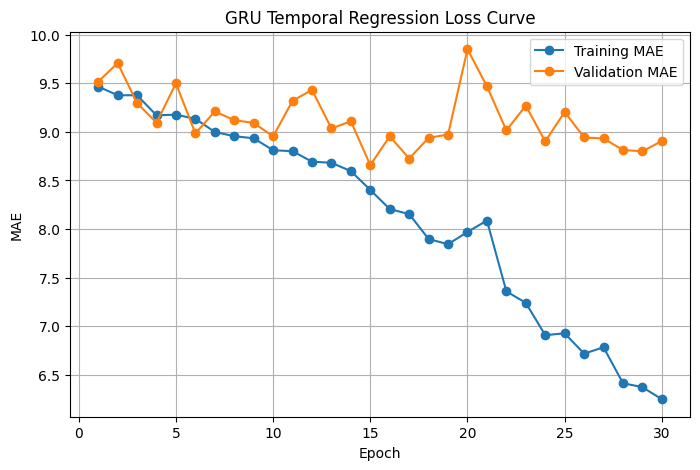

Saved: /content/drive/MyDrive/Tuwaiq Capstone Project/outputs/gru_temporal_regression_loss_curve.csv


In [21]:
@torch.no_grad()
def predict_z(model, loader):
    model.eval()
    all_pred_z, all_true_z, all_ex = [], [], []

    for xb, yb, exb in loader:
        xb = xb.to(device)
        pred_z = model(xb).detach().cpu().numpy()
        all_pred_z.append(pred_z)
        all_true_z.append(yb.numpy())
        all_ex.append(exb.numpy())

    return np.concatenate(all_pred_z), np.concatenate(all_true_z), np.concatenate(all_ex)


def evaluate_original_score(model, loader, true_scores):
    pred_z, true_z, ex_labels = predict_z(model, loader)
    pred_score = z_to_score(pred_z, ex_labels)
    true_score = np.asarray(true_scores, dtype=np.float32).reshape(-1)
    mae = mean_absolute_error(true_score, pred_score)
    rmse = np.sqrt(mean_squared_error(true_score, pred_score))
    r2 = r2_score(true_score, pred_score)
    return mae, rmse, r2, pred_score


criterion = nn.SmoothL1Loss(beta=0.5)
optimizer = torch.optim.AdamW(gru_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

EPOCHS = 120
PATIENCE = 15
best_gru_val_mae = float("inf")
best_gru_state = None
bad_epochs = 0
history = []

for epoch in range(1, EPOCHS + 1):
    gru_model.train()
    running_loss = 0.0

    for xb, yb, exb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred_z = gru_model(xb)
        loss = criterion(pred_z, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gru_model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_mae, train_rmse, train_r2, _ = evaluate_original_score(gru_model, train_eval_loader, y_score_train)
    val_mae, val_rmse, val_r2, _ = evaluate_original_score(gru_model, val_loader, y_score_val)
    scheduler.step(val_mae)

    history.append({
        "epoch": epoch,
        "train_loss_z": train_loss,
        "train_MAE": train_mae,
        "validation_MAE": val_mae,
        "train_RMSE": train_rmse,
        "validation_RMSE": val_rmse,
        "train_R2": train_r2,
        "validation_R2": val_r2,
        "lr": optimizer.param_groups[0]["lr"],
    })

    print(f"Epoch {epoch:03d} | Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f} | Val R2: {val_r2:.4f}")

    if val_mae < best_gru_val_mae - 1e-4:
        best_gru_val_mae = val_mae
        best_gru_state = copy.deepcopy(gru_model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_gru_state is not None:
    gru_model.load_state_dict(best_gru_state)

history_df = pd.DataFrame(history)
gru_val_mae, gru_val_rmse, gru_val_r2, gru_val_pred = evaluate_original_score(
    gru_model,
    val_loader,
    y_score_val,
)

print("\n=== GRU TEMPORAL REGRESSION — BEST VALIDATION ===")
print(f"MAE : {gru_val_mae:.4f}")
print(f"RMSE: {gru_val_rmse:.4f}")
print(f"R²  : {gru_val_r2:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_MAE"], marker="o", label="Training MAE")
plt.plot(history_df["epoch"], history_df["validation_MAE"], marker="o", label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("GRU Temporal Regression Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

gru_history_path = RESULTS_DIR / "gru_temporal_regression_loss_curve.csv"
history_df.to_csv(gru_history_path, index=False)
print("Saved:", gru_history_path)


## 18. Experiment 5 — TCN with Normalized Pose and Reference Features
This experiment tests a stronger regression approach using normalized pose, smoothness, reference-deviation features, and a TCN model.


### 18.1 Pose Normalization
This cell centers each pose around the hips and scales it by torso length to reduce participant and camera-position effects.


In [22]:
# Normalize pose by hip center and torso length.
def normalize_pose_hip_torso(X):
    X = np.asarray(X, dtype=np.float32).copy()

    xy = X[..., :2]
    conf = X[..., 2:3]

    left_hip = xy[:, :, 11, :]
    right_hip = xy[:, :, 12, :]
    hip_center = (left_hip + right_hip) / 2.0

    xy_centered = xy - hip_center[:, :, None, :]

    left_shoulder = xy[:, :, 5, :]
    right_shoulder = xy[:, :, 6, :]
    shoulder_center = (left_shoulder + right_shoulder) / 2.0

    torso_length = np.linalg.norm(shoulder_center - hip_center, axis=-1)
    torso_length = np.maximum(torso_length, 1e-3)

    xy_scaled = xy_centered / torso_length[:, :, None, None]
    X_norm = np.concatenate([xy_scaled, conf], axis=-1)

    return np.nan_to_num(X_norm, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


X_train_norm = normalize_pose_hip_torso(X_train)
X_val_norm = normalize_pose_hip_torso(X_val)
X_test_norm = normalize_pose_hip_torso(X_test)

print("Normalized train shape:", X_train_norm.shape)
print("Normalized val shape  :", X_val_norm.shape)
print("Normalized test shape :", X_test_norm.shape)

Normalized train shape: (2117, 45, 17, 3)
Normalized val shape  : (553, 45, 17, 3)
Normalized test shape : (340, 45, 17, 3)


### 18.2 Smoothness Features
This cell creates simple speed, acceleration, and jerk features to represent movement smoothness.


In [23]:
# Build video-level smoothness features from normalized pose.
def build_smoothness_features(X):
    xy = X[..., :2]

    velocity = np.diff(xy, axis=1)
    speed = np.linalg.norm(velocity, axis=-1)

    acceleration = np.diff(velocity, axis=1)
    accel_mag = np.linalg.norm(acceleration, axis=-1)

    jerk = np.diff(acceleration, axis=1)
    jerk_mag = np.linalg.norm(jerk, axis=-1)

    def stats(arr):
        return [
            arr.mean(axis=(1, 2)),
            arr.std(axis=(1, 2)),
            arr.max(axis=(1, 2)),
            np.percentile(arr, 75, axis=(1, 2)),
        ]

    features = stats(speed) + stats(accel_mag) + stats(jerk_mag)
    smoothness = np.vstack(features).T
    return np.nan_to_num(smoothness, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


smooth_train = build_smoothness_features(X_train_norm)
smooth_val = build_smoothness_features(X_val_norm)
smooth_test = build_smoothness_features(X_test_norm)

print("Smoothness feature shape:", smooth_train.shape)

Smoothness feature shape: (2117, 12)


### 18.3 Reference-Deviation Features
This cell builds a top-scoring reference trajectory for each exercise and measures how far each video is from it.


In [24]:
# Build reference trajectories using top-scoring training videos only.
def build_reference_trajectories(X, y_score, y_exercise, top_percent=0.25):
    references = {}

    for ex in sorted(np.unique(y_exercise)):
        ex = int(ex)
        idx = np.where(np.asarray(y_exercise) == ex)[0]
        ex_scores = np.asarray(y_score)[idx]

        cutoff = np.quantile(ex_scores, 1.0 - top_percent)
        top_idx = idx[ex_scores >= cutoff]

        if len(top_idx) == 0:
            top_idx = idx

        references[ex] = X[top_idx].mean(axis=0).astype(np.float32)

    return references


# Compute per-frame and video-level distance from the exercise reference.
def build_reference_deviation_features(X, y_exercise, references):
    frame_distance_rows = []
    summary_rows = []

    for i in range(len(X)):
        ex = int(y_exercise[i])
        ref = references[ex]

        diff = X[i, :, :, :2] - ref[:, :, :2]
        frame_dist = np.linalg.norm(diff, axis=-1).mean(axis=1)

        frame_distance_rows.append(frame_dist[:, None])
        summary_rows.append([
            frame_dist.mean(),
            frame_dist.std(),
            frame_dist.max(),
            frame_dist.min(),
            np.percentile(frame_dist, 25),
            np.percentile(frame_dist, 75),
        ])

    frame_distance = np.asarray(frame_distance_rows, dtype=np.float32)
    summary = np.asarray(summary_rows, dtype=np.float32)

    frame_distance = np.nan_to_num(frame_distance, nan=0.0, posinf=0.0, neginf=0.0)
    summary = np.nan_to_num(summary, nan=0.0, posinf=0.0, neginf=0.0)

    return frame_distance, summary


reference_trajectories = build_reference_trajectories(
    X_train_norm,
    y_score_train,
    y_exercise_train,
    top_percent=0.25,
)

ref_frame_train, ref_summary_train = build_reference_deviation_features(
    X_train_norm,
    y_exercise_train,
    reference_trajectories,
)
ref_frame_val, ref_summary_val = build_reference_deviation_features(
    X_val_norm,
    y_exercise_val,
    reference_trajectories,
)
ref_frame_test, ref_summary_test = build_reference_deviation_features(
    X_test_norm,
    y_exercise_test,
    reference_trajectories,
)

print("Reference frame-distance shape:", ref_frame_train.shape)
print("Reference summary feature shape:", ref_summary_train.shape)

Reference frame-distance shape: (2117, 45, 1)
Reference summary feature shape: (2117, 6)


### 18.4 TCN Sequence Preparation
This cell combines normalized pose with smoothness and reference features, then standardizes the sequence using training data only.


In [25]:
# Prepare sequence input for TCN.
def prepare_tcn_sequence(X_norm, smooth_features, ref_frame_features, ref_summary_features):
    N, T, K, C = X_norm.shape
    pose_flat = X_norm.reshape(N, T, K * C)

    video_features = np.concatenate([smooth_features, ref_summary_features], axis=1)
    video_features_repeated = np.repeat(video_features[:, None, :], T, axis=1)

    seq = np.concatenate([pose_flat, ref_frame_features, video_features_repeated], axis=2)
    return np.nan_to_num(seq, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


tcn_train_seq = prepare_tcn_sequence(X_train_norm, smooth_train, ref_frame_train, ref_summary_train)
tcn_val_seq = prepare_tcn_sequence(X_val_norm, smooth_val, ref_frame_val, ref_summary_val)
tcn_test_seq = prepare_tcn_sequence(X_test_norm, smooth_test, ref_frame_test, ref_summary_test)

# Standardize TCN input using training data only.
tcn_feature_mean = tcn_train_seq.reshape(-1, tcn_train_seq.shape[-1]).mean(axis=0)
tcn_feature_std = tcn_train_seq.reshape(-1, tcn_train_seq.shape[-1]).std(axis=0)
tcn_feature_std[tcn_feature_std < 1e-6] = 1.0

tcn_train_scaled = ((tcn_train_seq - tcn_feature_mean) / tcn_feature_std).astype(np.float32)
tcn_val_scaled = ((tcn_val_seq - tcn_feature_mean) / tcn_feature_std).astype(np.float32)
tcn_test_scaled = ((tcn_test_seq - tcn_feature_mean) / tcn_feature_std).astype(np.float32)

tcn_train_scaled = np.nan_to_num(tcn_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
tcn_val_scaled = np.nan_to_num(tcn_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
tcn_test_scaled = np.nan_to_num(tcn_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print("TCN train sequence:", tcn_train_scaled.shape)
print("TCN val sequence  :", tcn_val_scaled.shape)
print("TCN test sequence :", tcn_test_scaled.shape)

TCN train sequence: (2117, 45, 70)
TCN val sequence  : (553, 45, 70)
TCN test sequence : (340, 45, 70)


### 18.5 TCN Dataset and Model
This cell creates a TCN model with exercise embedding and an auxiliary exercise-classification head.


In [26]:
# Create TCN dataloaders and model.
class TCNSequenceDataset(Dataset):
    def __init__(self, X_seq, y_z, y_exercise, augment=False, noise_std=0.01):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.y_z = torch.tensor(y_z, dtype=torch.float32)
        self.y_exercise = torch.tensor(y_exercise, dtype=torch.long)
        self.augment = augment
        self.noise_std = noise_std

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        x = self.X_seq[idx].clone()
        y = self.y_z[idx]
        ex = self.y_exercise[idx]

        if self.augment and self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std

        return x, y, ex


class TCNBlock(nn.Module):
    def __init__(self, c_in, c_out, kernel_size=3, dilation=1, dropout=0.20):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2

        self.conv = nn.Conv1d(
            c_in,
            c_out,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation,
        )
        self.norm = nn.BatchNorm1d(c_out)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)
        self.residual = nn.Conv1d(c_in, c_out, kernel_size=1) if c_in != c_out else nn.Identity()

    def forward(self, x):
        out = self.conv(x)
        out = self.norm(out)
        out = self.act(out)
        out = self.drop(out)
        return out + self.residual(x)


class TCNQualityRegressor(nn.Module):
    def __init__(self, input_size, n_exercises=9, emb_dim=16, dropout=0.25):
        super().__init__()

        self.tcn = nn.Sequential(
            TCNBlock(input_size, 64, dilation=1, dropout=dropout),
            TCNBlock(64, 128, dilation=2, dropout=dropout),
            TCNBlock(128, 128, dilation=4, dropout=dropout),
        )

        self.exercise_embedding = nn.Embedding(n_exercises, emb_dim)

        self.shared_head = nn.Sequential(
            nn.LayerNorm(128 * 2 + emb_dim),
            nn.Linear(128 * 2 + emb_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.quality_head = nn.Linear(128, 1)
        self.exercise_head = nn.Linear(128, n_exercises)

    def forward(self, x, exercise_id):
        # x shape: batch, time, features
        x = x.transpose(1, 2)
        h = self.tcn(x)

        mean_pool = h.mean(dim=2)
        max_pool = h.max(dim=2).values
        ex_emb = self.exercise_embedding(exercise_id)

        features = torch.cat([mean_pool, max_pool, ex_emb], dim=1)
        shared = self.shared_head(features)

        pred_z = self.quality_head(shared).squeeze(1)
        pred_exercise = self.exercise_head(shared)

        return pred_z, pred_exercise


n_exercises = len(idx_to_exercise)

BATCH_SIZE_TCN = 64

tcn_train_loader = DataLoader(
    TCNSequenceDataset(tcn_train_scaled, y_train_z, y_exercise_train, augment=True, noise_std=0.01),
    batch_size=BATCH_SIZE_TCN,
    shuffle=True,
)
tcn_train_eval_loader = DataLoader(
    TCNSequenceDataset(tcn_train_scaled, y_train_z, y_exercise_train),
    batch_size=BATCH_SIZE_TCN,
    shuffle=False,
)
tcn_val_loader = DataLoader(
    TCNSequenceDataset(tcn_val_scaled, y_val_z, y_exercise_val),
    batch_size=BATCH_SIZE_TCN,
    shuffle=False,
)
tcn_test_loader = DataLoader(
    TCNSequenceDataset(tcn_test_scaled, y_test_z, y_exercise_test),
    batch_size=BATCH_SIZE_TCN,
    shuffle=False,
)

tcn_model = TCNQualityRegressor(
    input_size=tcn_train_scaled.shape[-1],
    n_exercises=n_exercises,
    emb_dim=16,
    dropout=0.25,
).to(device)

print(tcn_model)

TCNQualityRegressor(
  (tcn): Sequential(
    (0): TCNBlock(
      (conv): Conv1d(70, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
      (drop): Dropout(p=0.25, inplace=False)
      (residual): Conv1d(70, 64, kernel_size=(1,), stride=(1,))
    )
    (1): TCNBlock(
      (conv): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
      (drop): Dropout(p=0.25, inplace=False)
      (residual): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
    )
    (2): TCNBlock(
      (conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
      (drop): Dro

### 18.6 Train TCN with Early Stopping
This cell trains the TCN using regression loss plus a small auxiliary exercise-classification loss.


Epoch 001 | Train MAE: 9.6781 | Val MAE: 9.0418 | Val R2: 0.2243
Epoch 002 | Train MAE: 9.4406 | Val MAE: 9.0099 | Val R2: 0.2097
Epoch 003 | Train MAE: 9.3592 | Val MAE: 8.9566 | Val R2: 0.1989
Epoch 004 | Train MAE: 9.3063 | Val MAE: 8.7546 | Val R2: 0.1781
Epoch 005 | Train MAE: 9.1645 | Val MAE: 9.4980 | Val R2: 0.0414
Epoch 006 | Train MAE: 9.4239 | Val MAE: 9.3145 | Val R2: 0.0761
Epoch 007 | Train MAE: 8.9323 | Val MAE: 9.3701 | Val R2: 0.0338
Epoch 008 | Train MAE: 8.7707 | Val MAE: 8.7936 | Val R2: 0.1162
Epoch 009 | Train MAE: 8.9711 | Val MAE: 10.0908 | Val R2: -0.0885
Epoch 010 | Train MAE: 9.2196 | Val MAE: 9.8580 | Val R2: -0.1316
Epoch 011 | Train MAE: 8.4851 | Val MAE: 9.5438 | Val R2: -0.0852
Epoch 012 | Train MAE: 8.3479 | Val MAE: 9.4813 | Val R2: -0.0616
Epoch 013 | Train MAE: 8.2855 | Val MAE: 9.4553 | Val R2: -0.0198
Epoch 014 | Train MAE: 8.2185 | Val MAE: 9.3732 | Val R2: 0.0064
Epoch 015 | Train MAE: 8.0546 | Val MAE: 9.4299 | Val R2: -0.1041
Epoch 016 | Train 

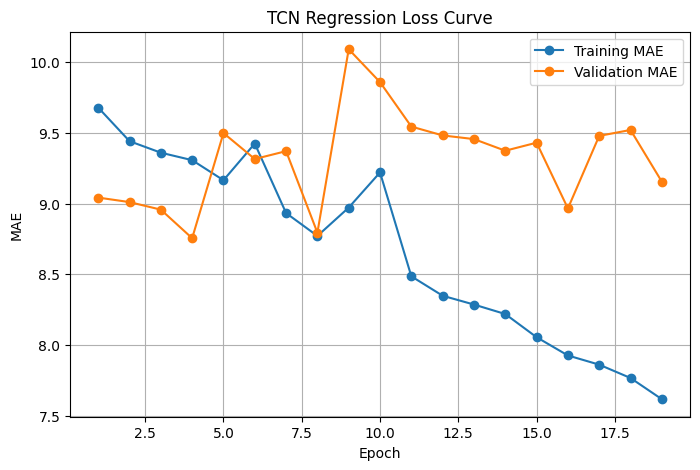

Saved: /content/drive/MyDrive/Tuwaiq Capstone Project/outputs/tcn_regression_loss_curve.csv


In [27]:
# Train the TCN and track validation MAE.
@torch.no_grad()
def predict_tcn_z(model, loader):
    model.eval()
    all_pred_z, all_true_z, all_ex = [], [], []

    for xb, yb, exb in loader:
        xb = xb.to(device)
        exb_device = exb.to(device)

        pred_z, pred_ex = model(xb, exb_device)

        all_pred_z.append(pred_z.detach().cpu().numpy())
        all_true_z.append(yb.numpy())
        all_ex.append(exb.numpy())

    return np.concatenate(all_pred_z), np.concatenate(all_true_z), np.concatenate(all_ex)


def evaluate_tcn_original_score(model, loader, true_scores):
    pred_z, true_z, ex_labels = predict_tcn_z(model, loader)
    pred_score = z_to_score(pred_z, ex_labels)
    true_score = np.asarray(true_scores, dtype=np.float32).reshape(-1)

    mae = mean_absolute_error(true_score, pred_score)
    rmse = np.sqrt(mean_squared_error(true_score, pred_score))
    r2 = r2_score(true_score, pred_score)

    return mae, rmse, r2, pred_score


quality_loss_fn = nn.SmoothL1Loss(beta=0.5)
exercise_loss_fn = nn.CrossEntropyLoss()

optimizer_tcn = torch.optim.AdamW(
    tcn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler_tcn = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_tcn,
    mode="min",
    factor=0.5,
    patience=5,
)

TCN_EPOCHS = 100
TCN_PATIENCE = 15
AUX_EXERCISE_LOSS_WEIGHT = 0.30

best_tcn_val_mae = float("inf")
best_tcn_state = None
tcn_bad_epochs = 0
tcn_history = []

for epoch in range(1, TCN_EPOCHS + 1):
    tcn_model.train()
    running_loss = 0.0

    for xb, yb, exb in tcn_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        exb = exb.to(device)

        optimizer_tcn.zero_grad()

        pred_z, pred_exercise = tcn_model(xb, exb)
        loss_quality = quality_loss_fn(pred_z, yb)
        loss_exercise = exercise_loss_fn(pred_exercise, exb)
        loss = loss_quality + AUX_EXERCISE_LOSS_WEIGHT * loss_exercise

        loss.backward()
        torch.nn.utils.clip_grad_norm_(tcn_model.parameters(), max_norm=1.0)
        optimizer_tcn.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(tcn_train_loader.dataset)

    tcn_train_mae, tcn_train_rmse, tcn_train_r2, _ = evaluate_tcn_original_score(
        tcn_model,
        tcn_train_eval_loader,
        y_score_train,
    )
    val_mae, val_rmse, val_r2, _ = evaluate_tcn_original_score(
        tcn_model,
        tcn_val_loader,
        y_score_val,
    )

    scheduler_tcn.step(val_mae)

    tcn_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_MAE": tcn_train_mae,
        "validation_MAE": val_mae,
        "train_RMSE": tcn_train_rmse,
        "validation_RMSE": val_rmse,
        "train_R2": tcn_train_r2,
        "validation_R2": val_r2,
        "lr": optimizer_tcn.param_groups[0]["lr"],
    })

    print(
        f"Epoch {epoch:03d} | "
        f"Train MAE: {tcn_train_mae:.4f} | "
        f"Val MAE: {val_mae:.4f} | "
        f"Val R2: {val_r2:.4f}"
    )

    if val_mae < best_tcn_val_mae - 1e-4:
        best_tcn_val_mae = val_mae
        best_tcn_state = copy.deepcopy(tcn_model.state_dict())
        tcn_bad_epochs = 0
    else:
        tcn_bad_epochs += 1

    if tcn_bad_epochs >= TCN_PATIENCE:
        print("Early stopping triggered.")
        break

if best_tcn_state is not None:
    tcn_model.load_state_dict(best_tcn_state)

tcn_history_df = pd.DataFrame(tcn_history)

tcn_val_mae, tcn_val_rmse, tcn_val_r2, tcn_val_pred = evaluate_tcn_original_score(
    tcn_model,
    tcn_val_loader,
    y_score_val,
)

print("\n=== TCN REGRESSION — BEST VALIDATION ===")
print(f"MAE : {tcn_val_mae:.4f}")
print(f"RMSE: {tcn_val_rmse:.4f}")
print(f"R²  : {tcn_val_r2:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(tcn_history_df["epoch"], tcn_history_df["train_MAE"], marker="o", label="Training MAE")
plt.plot(tcn_history_df["epoch"], tcn_history_df["validation_MAE"], marker="o", label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("TCN Regression Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

tcn_history_path = RESULTS_DIR / "tcn_regression_loss_curve.csv"
tcn_history_df.to_csv(tcn_history_path, index=False)
print("Saved:", tcn_history_path)

## 19. Validation Comparison and Model Selection
This cell compares all models using validation metrics only.


In [28]:
classification_comparison = pd.DataFrame({
    "Model": [
        "RF Baseline + Raw Pose",
        "RF + Engineered Features",
        "XGBoost + Engineered Features",
    ],
    "Accuracy": [baseline_val_accuracy, exp1_val_accuracy, exp2_val_accuracy],
    "Precision": [baseline_val_precision, exp1_val_precision, exp2_val_precision],
    "Recall": [baseline_val_recall, exp1_val_recall, exp2_val_recall],
    "F1": [baseline_val_f1, exp1_val_f1, exp2_val_f1],
})

regression_rows = [
    ["RF Baseline + Raw Pose", baseline_val_mae, baseline_val_rmse, baseline_val_r2],
    ["RF + Engineered Features", exp1_val_mae, exp1_val_rmse, exp1_val_r2],
    ["XGBoost + Engineered Features", exp2_val_mae, exp2_val_rmse, exp2_val_r2],
    ["RF + Kinematic Quality Features", quality_rf_val_mae, quality_rf_val_rmse, quality_rf_val_r2],
    ["ExtraTrees + Kinematic Quality Features", quality_extra_val_mae, quality_extra_val_rmse, quality_extra_val_r2],
    ["XGBoost + Kinematic Quality Features", quality_xgb_val_mae, quality_xgb_val_rmse, quality_xgb_val_r2],
]

if "gru_val_mae" in globals():
    regression_rows.append([
        "GRU Temporal + Kinematic Sequence",
        gru_val_mae,
        gru_val_rmse,
        gru_val_r2,
    ])

if "tcn_val_mae" in globals():
    regression_rows.append([
        "TCN + Normalized Pose + Reference Features",
        tcn_val_mae,
        tcn_val_rmse,
        tcn_val_r2,
    ])

regression_comparison = pd.DataFrame(regression_rows, columns=["Model", "MAE", "RMSE", "R²"])

print("=== Classification — Validation Comparison ===")
display(classification_comparison.round(4))

print("\n=== Regression — Validation Comparison ===")
display(regression_comparison.sort_values("MAE").reset_index(drop=True).round(4))

best_cls_name = classification_comparison.loc[classification_comparison["F1"].idxmax(), "Model"]
best_reg_name = regression_comparison.loc[regression_comparison["MAE"].idxmin(), "Model"]

print("\nBest classification model:", best_cls_name)
print("Best regression model:", best_reg_name)


=== Classification — Validation Comparison ===


,Model,Accuracy,Precision,Recall,F1
0,RF Baseline + Raw Pose,0.8499,0.8534,0.8499,0.8483
1,RF + Engineered Features,0.9168,0.9206,0.9168,0.9156
2,XGBoost + Engineered Features,0.9114,0.9198,0.9114,0.9100



=== Regression — Validation Comparison ===


,Model,MAE,RMSE,R²
0,GRU Temporal + Kinematic Sequence,8.6577,11.4771,0.1649
1,TCN + Normalized Pose + Reference Features,8.7546,11.3859,0.1781
2,RF + Kinematic Quality Features,9.1174,11.3444,0.1841
3,ExtraTrees + Kinematic Quality Features,9.2731,11.7137,0.1301
4,XGBoost + Kinematic Quality Features,9.5113,11.6705,0.1365
5,XGBoost + Engineered Features,10.0423,12.1686,0.0613
6,RF + Engineered Features,10.0947,12.0040,0.0865
7,RF Baseline + Raw Pose,10.4496,12.5330,0.0042



Best classification model: RF + Engineered Features
Best regression model: GRU Temporal + Kinematic Sequence


## 20. Model Improvement Curves
This cell plots validation improvement for classification and regression.


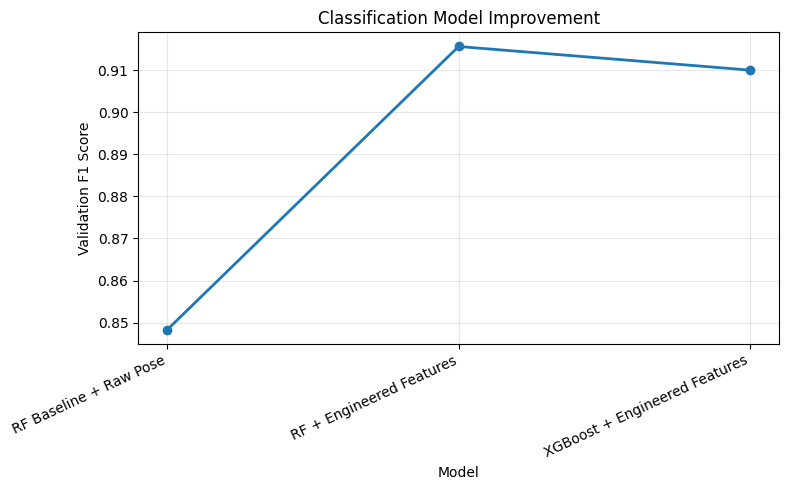

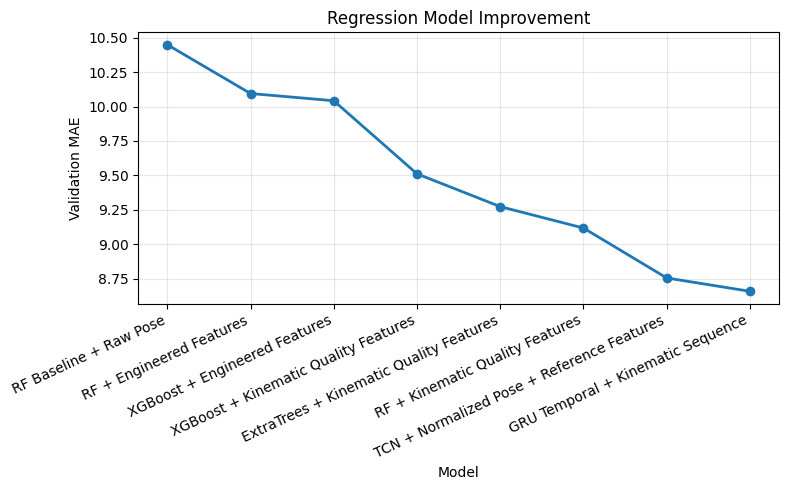

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(classification_comparison["Model"], classification_comparison["F1"], marker="o", linewidth=2)
plt.title("Classification Model Improvement")
plt.xlabel("Model")
plt.ylabel("Validation F1 Score")
plt.xticks(rotation=25, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plot_reg = regression_comparison.sort_values("MAE", ascending=False)
plt.plot(plot_reg["Model"], plot_reg["MAE"], marker="o", linewidth=2)
plt.title("Regression Model Improvement")
plt.xlabel("Model")
plt.ylabel("Validation MAE")
plt.xticks(rotation=25, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 21. Final Held-out Test Evaluation
This cell evaluates only the selected models on the test set.


In [30]:
classification_models = {
    "RF Baseline + Raw Pose": baseline_cls,
    "RF + Engineered Features": exp1_cls,
    "XGBoost + Engineered Features": xgb_classifier,
}
classification_test_features = {
    "RF Baseline + Raw Pose": X_test_raw,
    "RF + Engineered Features": X_test_eng,
    "XGBoost + Engineered Features": X_test_eng,
}

final_cls_model = classification_models[best_cls_name]
final_cls_X_test = classification_test_features[best_cls_name]
final_test_pred_class = final_cls_model.predict(final_cls_X_test)

final_test_accuracy = accuracy_score(y_exercise_test, final_test_pred_class)
final_test_precision = precision_score(y_exercise_test, final_test_pred_class, average="weighted", zero_division=0)
final_test_recall = recall_score(y_exercise_test, final_test_pred_class, average="weighted", zero_division=0)
final_test_f1 = f1_score(y_exercise_test, final_test_pred_class, average="weighted", zero_division=0)

X_test_quality = build_quality_feature_matrix(X_test, X_test_eng, y_exercise_test)

regression_models = {
    "RF Baseline + Raw Pose": baseline_reg,
    "RF + Engineered Features": exp1_reg,
    "XGBoost + Engineered Features": xgb_regressor,
    "RF + Kinematic Quality Features": quality_rf,
    "ExtraTrees + Kinematic Quality Features": quality_extra,
    "XGBoost + Kinematic Quality Features": quality_xgb,
}
regression_test_features = {
    "RF Baseline + Raw Pose": X_test_raw,
    "RF + Engineered Features": X_test_eng,
    "XGBoost + Engineered Features": X_test_eng,
    "RF + Kinematic Quality Features": X_test_quality,
    "ExtraTrees + Kinematic Quality Features": X_test_quality,
    "XGBoost + Kinematic Quality Features": X_test_quality,
}

if best_reg_name == "GRU Temporal + Kinematic Sequence":
    final_reg_model = gru_model
    final_test_mae, final_test_rmse, final_test_r2, final_test_pred_score = evaluate_original_score(
        gru_model,
        test_loader,
        y_score_test,
    )
elif best_reg_name == "TCN + Normalized Pose + Reference Features":
    final_reg_model = tcn_model
    final_test_mae, final_test_rmse, final_test_r2, final_test_pred_score = evaluate_tcn_original_score(
        tcn_model,
        tcn_test_loader,
        y_score_test,
    )
else:
    final_reg_model = regression_models[best_reg_name]
    final_reg_X_test = regression_test_features[best_reg_name]
    final_test_pred_score = np.clip(final_reg_model.predict(final_reg_X_test), 0, 100)
    final_test_mae = mean_absolute_error(y_score_test, final_test_pred_score)
    final_test_rmse = np.sqrt(mean_squared_error(y_score_test, final_test_pred_score))
    final_test_r2 = r2_score(y_score_test, final_test_pred_score)

train_mean_score = float(np.mean(y_score_train))
mean_baseline_pred = np.full_like(y_score_test, train_mean_score, dtype=np.float32)
mean_baseline_mae = mean_absolute_error(y_score_test, mean_baseline_pred)
mean_baseline_r2 = r2_score(y_score_test, mean_baseline_pred)
quality_pred = final_test_pred_score

print("=== FINAL CLASSIFICATION TEST RESULTS ===")
print("Selected model:", best_cls_name)
print(f"Accuracy : {final_test_accuracy:.4f}")
print(f"Precision: {final_test_precision:.4f}")
print(f"Recall   : {final_test_recall:.4f}")
print(f"F1-score : {final_test_f1:.4f}")

print("\n=== FINAL REGRESSION TEST RESULTS ===")
print("Selected model:", best_reg_name)
print(f"MAE : {final_test_mae:.4f}")
print(f"RMSE: {final_test_rmse:.4f}")
print(f"R²  : {final_test_r2:.4f}")

print("\n=== SANITY BASELINE ===")
print(f"Predict-train-mean MAE: {mean_baseline_mae:.4f}")
print(f"Predict-train-mean R² : {mean_baseline_r2:.4f}")
print("Improvement over mean baseline:", f"{mean_baseline_mae - final_test_mae:.4f} points")


=== FINAL CLASSIFICATION TEST RESULTS ===
Selected model: RF + Engineered Features
Accuracy : 0.8971
Precision: 0.9016
Recall   : 0.8971
F1-score : 0.8947

=== FINAL REGRESSION TEST RESULTS ===
Selected model: GRU Temporal + Kinematic Sequence
MAE : 8.3939
RMSE: 11.5844
R²  : 0.1503

=== SANITY BASELINE ===
Predict-train-mean MAE: 10.3305
Predict-train-mean R² : -0.0116
Improvement over mean baseline: 1.9366 points


## 22. Classification Test Details
This cell shows the confusion matrix and classification report.


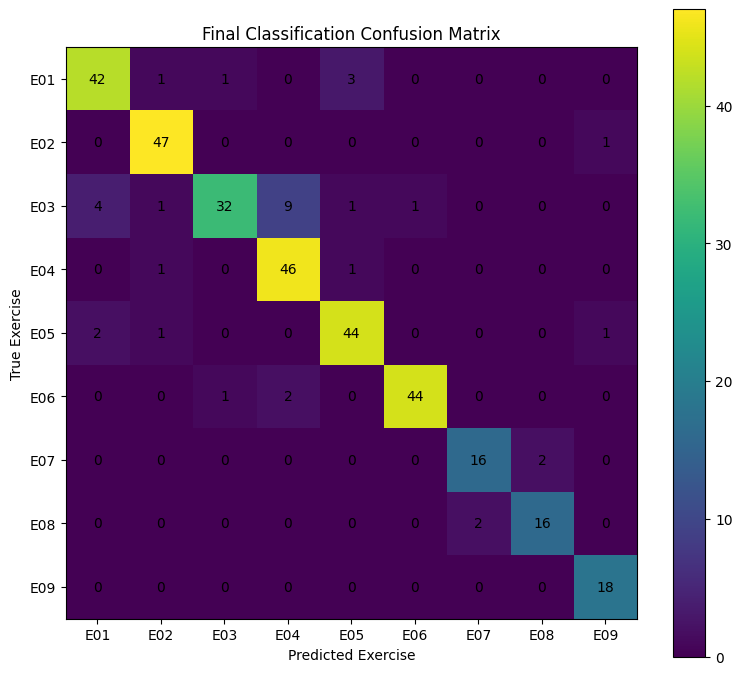


Classification report:
              precision    recall  f1-score   support

         E01       0.88      0.89      0.88        47
         E02       0.92      0.98      0.95        48
         E03       0.94      0.67      0.78        48
         E04       0.81      0.96      0.88        48
         E05       0.90      0.92      0.91        48
         E06       0.98      0.94      0.96        47
         E07       0.89      0.89      0.89        18
         E08       0.89      0.89      0.89        18
         E09       0.90      1.00      0.95        18

    accuracy                           0.90       340
   macro avg       0.90      0.90      0.90       340
weighted avg       0.90      0.90      0.89       340



In [31]:
# ============================================================
# 12.2 Classification Confusion Matrix
# ============================================================

class_labels = [idx_to_exercise[i] for i in sorted(idx_to_exercise)]

cm = confusion_matrix(
    y_exercise_test,
    final_test_pred_class,
    labels=sorted(idx_to_exercise)
)

plt.figure(figsize=(8, 7))
plt.imshow(cm, interpolation="nearest")
plt.title("Final Classification Confusion Matrix")
plt.xlabel("Predicted Exercise")
plt.ylabel("True Exercise")
plt.xticks(range(len(class_labels)), class_labels)
plt.yticks(range(len(class_labels)), class_labels)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

print("\nClassification report:")
print(
    classification_report(
        y_exercise_test,
        final_test_pred_class,
        labels=sorted(idx_to_exercise),
        target_names=class_labels,
        zero_division=0
    )
)


## 23. Regression Error Analysis
This cell analyzes where the final regression model makes the largest errors.


In [32]:
# ============================================================
# REGRESSION ERROR ANALYSIS — FINAL GLOBAL HELD-OUT TEST
# ============================================================

import os
import numpy as np
import pandas as pd

# These are created by the notebook's FULL HELD-OUT TEST cell.
assert "quality_pred" in globals(), "Run the FULL HELD-OUT TEST EVALUATION cell first."
assert "meta_test" in globals(), "Test metadata was not loaded."

y_true = np.asarray(y_score_test).reshape(-1)
y_pred = np.asarray(quality_pred).reshape(-1)

assert len(y_true) == len(y_pred) == len(meta_test), (
    f"Length mismatch: y_true={len(y_true)}, y_pred={len(y_pred)}, meta_test={len(meta_test)}"
)

# Build one clean dataframe for regression error analysis.
meta = meta_test.copy().reset_index(drop=True)
meta["true_score"] = y_true
meta["predicted_score"] = y_pred
meta["error"] = meta["predicted_score"] - meta["true_score"]
meta["absolute_error"] = np.abs(meta["error"])

# Extract camera angle and recording variation before running breakdowns.
if "Video Name" in meta.columns:
    video_parts = (
        meta["Video Name"]
        .astype(str)
        .str.replace(".mp4", "", regex=False)
        .str.split("_", expand=True)
    )

    if video_parts.shape[1] >= 4:
        meta["angle"] = video_parts[2].str.replace("A", "", regex=False)
        meta["variation"] = video_parts[3].str.replace("V", "", regex=False)
        print("Angle and variation columns were created.")
    else:
        print("Video name format is not enough to extract angle and variation.")
else:
    print("Video Name column was not found.")

print("=" * 64)
print("OVERALL REGRESSION ERROR")
print("=" * 64)
print(f"MAE                    : {meta['absolute_error'].mean():.4f}")
print(f"Median absolute error  : {meta['absolute_error'].median():.4f}")
print(f"90th percentile error  : {meta['absolute_error'].quantile(0.90):.4f}")
print(f"Maximum absolute error : {meta['absolute_error'].max():.4f}")

# Summarize error by one column.
def error_breakdown(column):
    if column not in meta.columns:
        print(f"\nSkipping {column!r}: column not found in test metadata.")
        return None

    result = (
        meta.groupby(column, observed=False)
        .agg(
            samples=("absolute_error", "size"),
            MAE=("absolute_error", "mean"),
            median_error=("absolute_error", "median"),
            bias=("error", "mean"),
        )
        .sort_values("MAE", ascending=False)
        .round(3)
    )

    print("\n" + "=" * 64)
    print(f"ERROR BY {column.upper()}")
    print("=" * 64)
    display(result)
    return result

exercise_errors = error_breakdown("exercise_code")
angle_errors = error_breakdown("angle")
variation_errors = error_breakdown("variation")

# Error by actual quality-score range.
meta["score_range"] = pd.cut(
    meta["true_score"],
    bins=[0, 60, 70, 80, 90, 100],
    include_lowest=True
)
score_errors = error_breakdown("score_range")

print("\n" + "=" * 64)
print("20 WORST GLOBAL-REGRESSION PREDICTIONS")
print("=" * 64)

candidate_columns = [
    "Video Name",
    "exercise_code",
    "participant_id",
    "angle",
    "variation",
    "true_score",
    "predicted_score",
    "error",
    "absolute_error",
]
show_columns = [c for c in candidate_columns if c in meta.columns]

worst_20 = (
    meta[show_columns]
    .sort_values("absolute_error", ascending=False)
    .head(20)
    .round(2)
)
display(worst_20)

print("\n" + "=" * 64)
print("BIAS / ERROR-BAND CHECK")
print("=" * 64)
print(f"Mean signed error : {meta['error'].mean():.3f}")
print(f"Underpredicted    : {(meta['error'] < 0).mean() * 100:.1f}%")
print(f"Overpredicted     : {(meta['error'] > 0).mean() * 100:.1f}%")
print(f"Within ±5 points  : {(meta['absolute_error'] <= 5).mean() * 100:.1f}%")
print(f"Within ±10 points : {(meta['absolute_error'] <= 10).mean() * 100:.1f}%")
print(f"Within ±15 points : {(meta['absolute_error'] <= 15).mean() * 100:.1f}%")

# Save analysis tables to Drive outputs.
error_dir = os.path.join(RESULTS_DIR, "regression_error_analysis")
os.makedirs(error_dir, exist_ok=True)

meta.to_csv(os.path.join(error_dir, "test_prediction_errors.csv"), index=False)
worst_20.to_csv(os.path.join(error_dir, "worst_20_predictions.csv"), index=False)

if exercise_errors is not None:
    exercise_errors.to_csv(os.path.join(error_dir, "error_by_exercise.csv"))
if angle_errors is not None:
    angle_errors.to_csv(os.path.join(error_dir, "error_by_angle.csv"))
if variation_errors is not None:
    variation_errors.to_csv(os.path.join(error_dir, "error_by_variation.csv"))
if score_errors is not None:
    score_errors.to_csv(os.path.join(error_dir, "error_by_score_range.csv"))

print("\nSaved error-analysis files to:")
print(error_dir)


Angle and variation columns were created.
OVERALL REGRESSION ERROR
MAE                    : 8.3939
Median absolute error  : 6.2827
90th percentile error  : 17.1732
Maximum absolute error : 47.4226

ERROR BY EXERCISE_CODE


,samples,MAE,median_error,bias
exercise_code,,,,
E09,18,22.518999,21.818001,-19.079
E02,48,12.879000,11.281000,3.410
E07,18,9.629000,9.568000,-1.825
E05,48,7.279000,6.283000,-2.965
E01,47,7.184000,5.538000,1.726
E03,48,7.092000,6.408000,-1.820
E08,18,6.260000,3.656000,4.565
E04,48,6.198000,5.000000,-0.138
E06,47,4.669000,3.144000,0.435



ERROR BY ANGLE


,samples,MAE,median_error,bias
angle,,,,
L,113,8.625,6.202,-1.330
F,114,8.548,6.585,-1.063
R,113,8.007,6.163,0.056



ERROR BY VARIATION


...


ERROR BY SCORE_RANGE


,samples,MAE,median_error,bias
score_range,,,,
"(-0.001, 60.0]",8,26.976999,30.377001,26.976999
"(60.0, 70.0]",45,10.826000,10.470000,10.300000
"(90.0, 100.0]",119,9.022000,5.030000,-8.704000
"(70.0, 80.0]",90,6.423000,5.072000,2.690000
"(80.0, 90.0]",78,6.401000,5.944000,-1.934000



20 WORST GLOBAL-REGRESSION PREDICTIONS


,Video Name,exercise_code,participant_id,angle,variation,true_score,predicted_score,error,absolute_error
330,E09_P23_AL_VLJ_GM,E09,23,L,LJ,97.620003,50.200001,-47.419998,47.419998
325,E09_P23_AF_VLL_GM,E09,23,F,LL,100.000000,53.740002,-46.259998,46.259998
208,E02_P23_AR_VFL_GM,E02,23,R,FL,35.709999,81.059998,45.349998,45.349998
202,E02_P23_AL_VFL_GM,E02,23,L,FL,35.709999,75.980003,40.259998,40.259998
329,E09_P23_AL_VHJ_GM,E09,23,L,HJ,97.620003,57.860001,-39.759998,39.759998
196,E02_P23_AF_VFL_GM,E02,23,F,FL,35.709999,74.250000,38.540001,38.540001
331,E09_P23_AL_VLL_GM,E09,23,L,LL,100.000000,62.540001,-37.459999,37.459999
324,E09_P23_AF_VLJ_GM,E09,23,F,LJ,97.620003,60.880001,-36.740002,36.740002
336,E09_P23_AR_VLJ_GM,E09,23,R,LJ,97.620003,63.790001,-33.830002,33.830002
178,E01_P23_AF_VFL_GM,E01,23,F,FL,50.950001,83.250000,32.290001,32.290001



BIAS / ERROR-BAND CHECK
Mean signed error : -0.780
Underpredicted    : 55.6%
Overpredicted     : 42.9%
Within ±5 points  : 41.5%
Within ±10 points : 69.4%
Within ±15 points : 86.5%

Saved error-analysis files to:
/content/drive/MyDrive/Tuwaiq Capstone Project/outputs/regression_error_analysis


## 24. Participant and Detailed Error Checks
This cell checks participant-level errors and participant-exercise error patterns.

In [33]:
# Check participant-level errors and participant-exercise patterns.
participant_errors = error_breakdown("participant_id")

if "participant_id" in meta.columns:
    without_p23 = meta["participant_id"].astype(str) != "23"

    if without_p23.any() and (~without_p23).any():
        mae_without_p23 = mean_absolute_error(
            meta.loc[without_p23, "true_score"],
            meta.loc[without_p23, "predicted_score"],
        )
        mae_p23_only = mean_absolute_error(
            meta.loc[~without_p23, "true_score"],
            meta.loc[~without_p23, "predicted_score"],
        )

        print("MAE with all test participants:", meta["absolute_error"].mean())
        print("MAE without participant 23:", mae_without_p23)
        print("MAE for participant 23 only:", mae_p23_only)
        print("Samples without participant 23:", without_p23.sum())
        print("Samples for participant 23:", (~without_p23).sum())

if {"participant_id", "exercise_code"}.issubset(meta.columns):
    print("\nERROR BY PARTICIPANT + EXERCISE")
    display(
        meta.groupby(["participant_id", "exercise_code"])
        .agg(
            samples=("absolute_error", "size"),
            MAE=("absolute_error", "mean"),
            bias=("error", "mean"),
        )
        .sort_values("MAE", ascending=False)
        .round(3)
        .head(20)
    )



ERROR BY PARTICIPANT_ID


,samples,MAE,median_error,bias
participant_id,,,,
23,162,9.725,7.350,-0.694
11,70,7.994,7.436,0.164
13,108,6.657,4.968,-1.520


MAE with all test participants: 8.39394
MAE without participant 23: 7.182698726654053
MAE for participant 23 only: 9.724808692932129
Samples without participant 23: 178
Samples for participant 23: 162

ERROR BY PARTICIPANT + EXERCISE


samples        MAE    bias
participant_id exercise_code                            
23             E09                 18  22.518999 -19.079
               E02                 18  14.805000  13.490
11             E02                 12  11.733000  -7.007
13             E02                 18  11.718000   0.274
23             E07                 18   9.629000  -1.825
11             E05                 12   9.398000  -8.450
23             E01                 18   8.959000   3.326
11             E04                 12   8.518000   8.297
23             E03                 18   7.897000  -5.736
11             E03                 12   7.311000   7.311
13             E01                 18   7.271000   2.403
23             E05                 18   7.062000   1.841
11             E06                 11   6.417000   2.879
23             E08                 18   6.260000   4.565
13             E03                 18   6.140000  -3.991
               E05                 18   6.084000  -4.114
23             E04                 18   5.906000  -4.349
13             E04                 18   4.942000  -1.550
23             E06                 18   4.486000   1.517
11             E01                 11   4.136000  -2.001

## 25. Correct and Incorrect Examples
This cell shows example predictions for classification and regression.


In [34]:
correct_mask = y_exercise_test == final_test_pred_class
incorrect_mask = ~correct_mask

correct_columns = [c for c in ["Video Name", "participant_id", "exercise_code", "quality_score"] if c in meta_test.columns]
correct_examples = meta_test.loc[correct_mask, correct_columns].copy()
incorrect_examples = meta_test.loc[incorrect_mask, correct_columns].copy()

correct_examples["predicted_exercise"] = [idx_to_exercise[int(v)] for v in final_test_pred_class[correct_mask]]
incorrect_examples["predicted_exercise"] = [idx_to_exercise[int(v)] for v in final_test_pred_class[incorrect_mask]]

print("Correct predictions:", len(correct_examples))
print("Incorrect predictions:", len(incorrect_examples))

print("\n=== Correct examples ===")
display(correct_examples.head(10))

print("\n=== Incorrect examples ===")
display(incorrect_examples.head(10))

regression_examples = meta_test[correct_columns].copy()
regression_examples["predicted_quality_score"] = final_test_pred_score
regression_examples["absolute_error"] = (np.asarray(y_score_test) - final_test_pred_score).astype(float)
regression_examples["absolute_error"] = regression_examples["absolute_error"].abs()

print("\n=== Smallest regression errors ===")
display(regression_examples.sort_values("absolute_error").head(10))

print("\n=== Largest regression errors ===")
display(regression_examples.sort_values("absolute_error", ascending=False).head(10))


Correct predictions: 305
Incorrect predictions: 35

=== Correct examples ===


,Video Name,participant_id,exercise_code,quality_score,predicted_exercise
0,E01_P11_AF_VFL_GF,11,E01,85.714286,E01
1,E01_P11_AF_VLL_GF,11,E01,84.285714,E01
2,E01_P11_AF_VML_GF,11,E01,81.904762,E01
3,E01_P11_AF_VO_GF,11,E01,84.285714,E01
4,E01_P11_AL_VFL_GF,11,E01,70.000000,E01
5,E01_P11_AL_VLL_GF,11,E01,84.285714,E01
6,E01_P11_AL_VML_GF,11,E01,81.904762,E01
7,E01_P11_AL_VO_GF,11,E01,81.428571,E01
8,E01_P11_AR_VFL_GF,11,E01,85.714286,E01
9,E01_P11_AR_VLL_GF,11,E01,84.285714,E01



=== Incorrect examples ===


,Video Name,participant_id,exercise_code,quality_score,predicted_exercise
18,E01_P13_AL_VHJ_GF,13,E01,70.000000,E03
21,E01_P13_AL_VML_GF,13,E01,72.380952,E02
24,E01_P13_AR_VHJ_GF,13,E01,70.000000,E05
48,E02_P13_AL_VHJ_GF,13,E02,92.857143,E09
59,E03_P11_AF_VFL_GF,11,E03,69.047619,E04
61,E03_P11_AF_VML_GF,11,E03,71.428571,E04
62,E03_P11_AF_VO_GF,11,E03,66.666667,E05
63,E03_P11_AL_VFL_GF,11,E03,69.047619,E04
65,E03_P11_AL_VML_GF,11,E03,71.428571,E04
66,E03_P11_AL_VO_GF,11,E03,66.666667,E06



=== Smallest regression errors ===


,Video Name,participant_id,exercise_code,quality_score,predicted_quality_score,absolute_error
306,E08_P23_AF_VLJ_GM,23,E08,100.000000,100.000000,0.000000
304,E08_P23_AF_VFL_GM,23,E08,100.000000,100.000000,0.000000
314,E08_P23_AL_VML_GM,23,E08,100.000000,100.000000,0.000000
310,E08_P23_AL_VFL_GM,23,E08,100.000000,100.000000,0.000000
308,E08_P23_AF_VML_GM,23,E08,100.000000,100.000000,0.000000
212,E02_P23_AR_VML_GM,23,E02,70.000000,70.039581,0.039581
334,E09_P23_AR_VFL_GM,23,E09,74.190476,74.241325,0.050850
251,E05_P23_AF_VHJ_GM,23,E05,81.904762,81.957352,0.052589
154,E06_P11_AL_VLL_GF,11,E06,95.238095,95.131134,0.106964
118,E04_P13_AR_VO_GF,13,E04,71.428571,71.542290,0.113716



=== Largest regression errors ===


,Video Name,participant_id,exercise_code,quality_score,predicted_quality_score,absolute_error
330,E09_P23_AL_VLJ_GM,23,E09,97.619048,50.196426,47.422623
325,E09_P23_AF_VLL_GM,23,E09,100.000000,53.740494,46.259506
208,E02_P23_AR_VFL_GM,23,E02,35.714286,81.061180,45.346893
202,E02_P23_AL_VFL_GM,23,E02,35.714286,75.977806,40.263519
329,E09_P23_AL_VHJ_GM,23,E09,97.619048,57.859760,39.759289
196,E02_P23_AF_VFL_GM,23,E02,35.714286,74.253746,38.539459
331,E09_P23_AL_VLL_GM,23,E09,100.000000,62.542030,37.457970
324,E09_P23_AF_VLJ_GM,23,E09,97.619048,60.879700,36.739349
336,E09_P23_AR_VLJ_GM,23,E09,97.619048,63.788662,33.830387
178,E01_P23_AF_VFL_GM,23,E01,50.952381,83.245255,32.292873


## 26. Save Final Models and Results
This cell saves selected models, validation comparisons, and final test results.


In [ ]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# Save the FINAL classification model selected on validation.
# ------------------------------------------------------------------
classification_model_path = MODELS_DIR / "final_classification_model.joblib"
joblib.dump(final_cls_model, classification_model_path)

# ------------------------------------------------------------------
# Save ONLY the regression artifact that corresponds to the selected
# validation winner. This prevents a stale RandomForest .joblib from
# being mistaken for the final GRU/TCN model.
# ------------------------------------------------------------------
legacy_regression_joblib = MODELS_DIR / "final_regression_model.joblib"
gru_regression_path = MODELS_DIR / "final_regression_model_gru.pt"
tcn_regression_path = MODELS_DIR / "final_regression_model_tcn.pt"

if best_reg_name == "GRU Temporal + Kinematic Sequence":
    # Remove stale sklearn artifact from an older run, if present.
    if legacy_regression_joblib.exists():
        legacy_regression_joblib.unlink()

    checkpoint = {
        "artifact_format_version": 2,
        "model_type": "GRUQualityRegressor",
        "model_state_dict": final_reg_model.state_dict(),
        "model_config": {
            "input_size": int(seq_train_scaled.shape[-1]),
            "hidden_size": 128,
            "num_layers": 2,
            "dropout": 0.25,
            "bidirectional": True,
        },
        "input_size": int(seq_train_scaled.shape[-1]),
        "feature_mean": np.asarray(feature_mean, dtype=np.float32),
        "feature_std": np.asarray(feature_std, dtype=np.float32),
        "score_stats": score_stats,
        "idx_to_exercise": idx_to_exercise,
        "best_regression_model": best_reg_name,
        "regression_feature_mode": "temporal_kinematic_sequence",
        "selection_metric": "validation MAE",
        "validation_mae": float(gru_val_mae),
        "final_test_mae": float(final_test_mae),
        "final_test_rmse": float(final_test_rmse),
        "final_test_r2": float(final_test_r2),
        "random_seed": int(RANDOM_SEED),
    }
    torch.save(checkpoint, gru_regression_path)
    final_regression_model_path = gru_regression_path

elif best_reg_name == "TCN + Normalized Pose + Reference Features":
    # Remove stale sklearn artifact from an older run, if present.
    if legacy_regression_joblib.exists():
        legacy_regression_joblib.unlink()

    checkpoint = {
        "artifact_format_version": 2,
        "model_type": type(final_reg_model).__name__,
        "model_state_dict": final_reg_model.state_dict(),
        "input_size": int(tcn_train_scaled.shape[-1]),
        "feature_mean": np.asarray(tcn_feature_mean, dtype=np.float32),
        "feature_std": np.asarray(tcn_feature_std, dtype=np.float32),
        "score_stats": score_stats,
        "idx_to_exercise": idx_to_exercise,
        "reference_trajectories": reference_trajectories,
        "best_regression_model": best_reg_name,
        "regression_feature_mode": "tcn_normalized_pose_reference_features",
        "selection_metric": "validation MAE",
        "validation_mae": float(tcn_val_mae),
        "final_test_mae": float(final_test_mae),
        "final_test_rmse": float(final_test_rmse),
        "final_test_r2": float(final_test_r2),
        "random_seed": int(RANDOM_SEED),
    }
    torch.save(checkpoint, tcn_regression_path)
    final_regression_model_path = tcn_regression_path

else:
    # sklearn/XGBoost regression winner
    joblib.dump(final_reg_model, legacy_regression_joblib)
    final_regression_model_path = legacy_regression_joblib

# ------------------------------------------------------------------
# Record feature mode and selection metadata.
# ------------------------------------------------------------------
if best_reg_name == "GRU Temporal + Kinematic Sequence":
    regression_feature_mode = "temporal_kinematic_sequence"
elif best_reg_name == "TCN + Normalized Pose + Reference Features":
    regression_feature_mode = "tcn_normalized_pose_reference_features"
elif best_reg_name in [
    "RF + Kinematic Quality Features",
    "ExtraTrees + Kinematic Quality Features",
    "XGBoost + Kinematic Quality Features",
]:
    regression_feature_mode = "kinematic_quality_plus_exercise"
elif best_reg_name == "RF Baseline + Raw Pose":
    regression_feature_mode = "raw_pose"
else:
    regression_feature_mode = "basic_engineered"

model_selection = {
    "best_classification_model": best_cls_name,
    "best_regression_model": best_reg_name,
    "classification_model_file": classification_model_path.name,
    "regression_model_file": final_regression_model_path.name,
    "classification_selection_metric": "validation weighted F1",
    "regression_selection_metric": "validation MAE",
    "regression_feature_mode": regression_feature_mode,
    "best_rf_trees": int(best_rf_trees) if "best_rf_trees" in globals() else None,
    "raw_pose_shape": [45, 17, 3],
    "raw_feature_count": int(X_train_raw.shape[1]),
    "engineered_feature_count": int(X_train_eng.shape[1]),
    "kinematic_quality_feature_count": int(X_train_quality.shape[1]),
    "tcn_sequence_feature_count": int(tcn_train_scaled.shape[-1]) if "tcn_train_scaled" in globals() else None,
    "final_test_classification_f1": float(final_test_f1),
    "final_test_regression_mae": float(final_test_mae),
    "final_test_regression_rmse": float(final_test_rmse),
    "final_test_regression_r2": float(final_test_r2),
    "mean_baseline_test_mae": float(mean_baseline_mae),
    "random_seed": int(RANDOM_SEED),
}

with open(RESULTS_DIR / "model_selection.json", "w", encoding="utf-8") as f:
    json.dump(model_selection, f, indent=2)

classification_comparison.to_csv(
    RESULTS_DIR / "classification_validation_comparison.csv", index=False
)
regression_comparison.to_csv(
    RESULTS_DIR / "regression_validation_comparison.csv", index=False
)

final_test_results = pd.DataFrame({
    "Task": ["Classification", "Regression"],
    "Selected Model": [best_cls_name, best_reg_name],
    "Primary Metric": ["F1", "MAE"],
    "Test Score": [final_test_f1, final_test_mae],
})
final_test_results.to_csv(RESULTS_DIR / "final_test_results.csv", index=False)

print("Saved classification model:", classification_model_path)
print("Saved regression model    :", final_regression_model_path)
print("Saved result files to     :", RESULTS_DIR)

# Important consistency assertion: when GRU wins, there must NOT be a
# final_regression_model.joblib file left over from an earlier RF run.
if best_reg_name == "GRU Temporal + Kinematic Sequence":
    assert final_regression_model_path.suffix == ".pt"
    assert not legacy_regression_joblib.exists()
    assert final_regression_model_path.exists()


## 27. LLM Feedback Payload
This cell creates the structured result that is passed to the LLM.


In [36]:
@dataclass
class InferenceSummary:
    exercise: str
    classification_confidence: float
    ai_estimated_quality_score: float
    repetitions: Optional[int] = None
    observations: Optional[List[str]] = None
    previous_quality_score: Optional[float] = None


def build_llm_payload(
    exercise: str,
    classification_confidence: float,
    ai_estimated_quality_score: float,
    repetitions: Optional[int] = None,
    observations: Optional[List[str]] = None,
    previous_quality_score: Optional[float] = None,
) -> Dict[str, Any]:
    summary = InferenceSummary(
        exercise=str(exercise),
        classification_confidence=float(np.clip(classification_confidence, 0.0, 1.0)),
        ai_estimated_quality_score=float(np.clip(ai_estimated_quality_score, 0.0, 100.0)),
        repetitions=None if repetitions is None else int(repetitions),
        observations=list(observations or []),
        previous_quality_score=None if previous_quality_score is None else float(np.clip(previous_quality_score, 0.0, 100.0)),
    )
    return asdict(summary)

print("Structured LLM payload builder ready.")


Structured LLM payload builder ready.


## 28. LLM Safety and Fallback
This cell adds a safe fallback response and blocks unsupported medical claims.


In [37]:
DISCLAIMER = (
    "This feedback is for exercise-support purposes only and is not a medical diagnosis "
    "or a replacement for guidance from a qualified physiotherapist."
)


def deterministic_feedback(payload: Dict[str, Any]) -> str:
    exercise = payload["exercise"]
    score = payload["ai_estimated_quality_score"]
    confidence = payload["classification_confidence"]

    if score >= 85:
        level = "excellent"
    elif score >= 70:
        level = "good"
    else:
        level = "needs more control"

    return (
        f"Exercise detected: {exercise} with {confidence:.0%} confidence. "
        f"The AI-estimated movement quality is {score:.1f}/100, which looks {level}. "
        "Move slowly, keep the movement controlled, and keep your full body visible to the camera. "
        + DISCLAIMER
    )


UNSAFE_CLAIM_PATTERNS = [
    r"\byou have (?:an? )?[a-z]",
    r"\byou suffer from\b",
    r"\byour diagnosis is\b",
    r"\byou are diagnosed with\b",
    r"\bthis indicates (?:an? )?(?:injury|disease|disorder)\b",
    r"\byou need (?:medical )?treatment\b",
    r"\bi prescribe\b",
    r"\byou should take (?:medication|medicine|drugs?)\b",
]


def feedback_is_safe(text: str) -> bool:
    lowered = text.lower()
    return not any(re.search(pattern, lowered) for pattern in UNSAFE_CLAIM_PATTERNS)


def clean_feedback(text: str) -> str:
    text = re.sub(r"\*\*(.*?)\*\*", r"\1", text)
    text = text.replace("No specific movement observations were provided.", "")
    return " ".join(text.split())


def ensure_safe_feedback(text: str, payload: Dict[str, Any]) -> str:
    text = clean_feedback(text)
    if not text or not feedback_is_safe(text):
        return deterministic_feedback(payload)
    if "not a medical diagnosis" not in text.lower():
        text = text.rstrip() + " " + DISCLAIMER
    return text

print("LLM safety helpers ready.")


LLM safety helpers ready.


## 29. LLM Feedback Provider
This cell calls the LLM when an API key exists, otherwise it uses the fallback.


In [38]:
def llm_feedback(payload: Dict[str, Any], model: str = "gpt-5.6-luna") -> str:
    api_key = os.getenv("OPENAI_API_KEY")
    if not api_key:
        print("OPENAI_API_KEY not configured — using deterministic fallback.")
        return deterministic_feedback(payload)

    try:
        from openai import OpenAI
    except ImportError:
        import sys
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openai"])
        from openai import OpenAI

    client = OpenAI(api_key=api_key)

    system_prompt = """
You are a supportive physiotherapy exercise assistant.
Use only the provided AI analysis result.
Do not give medical diagnosis.
Do not mention missing observations.
Do not say "No specific movement observations were provided".
If detailed movement observations are not available, give general supportive feedback based on exercise name, confidence, quality score, and quality level.
Write simple patient-friendly feedback in 2 to 4 sentences.
Rules:
- Score 85 or higher: movement quality looks excellent overall.
- Score 70 to 84: movement quality is good but can improve.
- Score below 70: movement may need more control.
- Mention slow movement, control, and keeping the full body visible.
- End with a clear note that this is exercise support only and not a medical diagnosis.
""".strip()

    user_prompt = "Generate user feedback from this validated result:\n" + json.dumps(payload, indent=2)

    try:
        response = client.responses.create(
            model=model,
            instructions=system_prompt,
            input=user_prompt,
            max_output_tokens=250,
        )
        return ensure_safe_feedback(response.output_text.strip(), payload)
    except Exception as exc:
        print(f"OpenAI provider failed ({type(exc).__name__}: {exc}) — using deterministic fallback.")
        return deterministic_feedback(payload)


print("LLM provider ready.")


LLM provider ready.


## 30. End-to-End Sample Feedback
This cell takes one real test sample and generates the final user feedback.


In [39]:
def predict_single_quality(sample_idx: int):
    if best_reg_name == "GRU Temporal + Kinematic Sequence":
        gru_model.eval()
        xb = torch.tensor(seq_test_scaled[sample_idx:sample_idx+1], dtype=torch.float32).to(device)
        with torch.no_grad():
            pred_z = gru_model(xb).detach().cpu().numpy()
        return float(z_to_score(pred_z, [int(y_exercise_test[sample_idx])])[0])

    if best_reg_name == "RF Baseline + Raw Pose":
        reg_features = X_test_raw[sample_idx:sample_idx+1]
    elif best_reg_name in ["RF + Engineered Features", "XGBoost + Engineered Features"]:
        reg_features = X_test_eng[sample_idx:sample_idx+1]
    else:
        reg_features = X_test_quality[sample_idx:sample_idx+1]

    return float(np.clip(final_reg_model.predict(reg_features)[0], 0, 100))


sample_idx = 0

if best_cls_name == "RF Baseline + Raw Pose":
    cls_features = X_test_raw[sample_idx:sample_idx+1]
else:
    cls_features = X_test_eng[sample_idx:sample_idx+1]

pred_exercise_idx = int(final_cls_model.predict(cls_features)[0])
true_exercise_idx = int(y_exercise_test[sample_idx])

if hasattr(final_cls_model, "predict_proba"):
    class_confidence = float(np.max(final_cls_model.predict_proba(cls_features)[0]))
else:
    class_confidence = 1.0

predicted_exercise = idx_to_exercise[pred_exercise_idx]
true_exercise = idx_to_exercise[true_exercise_idx]
predicted_quality = predict_single_quality(sample_idx)
true_quality = float(y_score_test[sample_idx])

payload = build_llm_payload(
    exercise=predicted_exercise,
    classification_confidence=class_confidence,
    ai_estimated_quality_score=predicted_quality,
)
feedback = llm_feedback(payload)

print("TRUE EXERCISE:", true_exercise)
print("PREDICTED EXERCISE:", predicted_exercise)
print("TRUE QUALITY:", round(true_quality, 2))
print("PREDICTED QUALITY:", round(predicted_quality, 2))
print("\nPAYLOAD")
print(json.dumps(payload, indent=2))
print("\nFEEDBACK")
print(feedback)


OPENAI_API_KEY not configured — using deterministic fallback.
TRUE EXERCISE: E01
PREDICTED EXERCISE: E01
TRUE QUALITY: 85.71
PREDICTED QUALITY: 82.39

PAYLOAD
{
  "exercise": "E01",
  "classification_confidence": 0.98,
  "ai_estimated_quality_score": 82.39408874511719,
  "repetitions": null,
  "observations": [],
  "previous_quality_score": null
}

FEEDBACK
Exercise detected: E01 with 98% confidence. The AI-estimated movement quality is 82.4/100, which looks good. Move slowly, keep the movement controlled, and keep your full body visible to the camera. This feedback is for exercise-support purposes only and is not a medical diagnosis or a replacement for guidance from a qualified physiotherapist.


## 31. Final Summary
This cell prints the key final results for the report and presentation.


In [40]:
summary = {
    "data_dir_used": str(PREPARED_DATA_DIR),
    "train_videos": int(len(X_train)),
    "validation_videos": int(len(X_val)),
    "test_videos": int(len(X_test)),
    "best_classification_model": best_cls_name,
    "test_classification_f1": float(final_test_f1),
    "best_regression_model": best_reg_name,
    "test_regression_mae": float(final_test_mae),
    "test_regression_rmse": float(final_test_rmse),
    "test_regression_r2": float(final_test_r2),
    "mean_baseline_mae": float(mean_baseline_mae),
    "within_5_percent": float((np.abs(final_test_pred_score - y_score_test) <= 5).mean() * 100),
    "within_10_percent": float((np.abs(final_test_pred_score - y_score_test) <= 10).mean() * 100),
    "within_15_percent": float((np.abs(final_test_pred_score - y_score_test) <= 15).mean() * 100),
}

summary_df = pd.DataFrame([summary])
display(summary_df.T.rename(columns={0: "value"}))
summary_df.to_csv(RESULTS_DIR / "final_summary.csv", index=False)
print("Saved:", RESULTS_DIR / "final_summary.csv")


,value
data_dir_used,/content/drive/MyDrive/Tuwaiq Capstone Project...
train_videos,2117
validation_videos,553
test_videos,340
best_classification_model,RF + Engineered Features
test_classification_f1,0.894735
best_regression_model,GRU Temporal + Kinematic Sequence
test_regression_mae,8.39394
test_regression_rmse,11.584387
test_regression_r2,0.150264


Saved: /content/drive/MyDrive/Tuwaiq Capstone Project/outputs/final_summary.csv
